# 가설 2: 라이트 유저의 높은 긍정률 — "왜 재밌다고 했는데 엔딩까지 안 갔는가?"

> **가설**: 2~14h 유저는 긍정률이 높지만, 칭찬하는 요소와 불만 요소의 구성이 플레이타임에 따라 질적으로 변한다.  
> 이 변화 패턴이 "왜 재밌다고 했는데 엔딩까지 안 갔는가"를 설명해줄 것이다.
>
> **핵심 질문**: 엔딩(~20h)까지 이끌 '힘'이 어디서 부족했는가?  
> (DLC/추가 콘텐츠 문제가 아님. 메인 콘텐츠 안에서의 모멘텀 문제.)

## 데이터 레이어
| 레이어 | 테이블 | 건수 | 강점 | 약점 |
|--------|--------|------|------|------|
| **전문 (토큰화)** | `cleaned_reviews_en` + `cleaned_reviews_ko` | ~55,000 | 전수 분석, 통계적 견고함 | 키워드 수준, "왜"를 직접 답 못함 |
| **샘플 (LLM 분류)** | `pos_reviews_classified` + `neg_reviews_classified` | ~6,000 | aspect/category 레이블, 의미 해석 가능 | 샘플링, 빈별 건수 제한 |

**활용 전략**: 전문 데이터로 패턴 발견 → LLM 데이터로 의미 해석 → 교차 검증

## 분석 흐름
```
STEP 0: 데이터 로드 + 세팅
STEP 1: 긍정률 곡선 (flat 확인)
STEP 2: [전문] LDA 토픽 구성비 변화
STEP 3: [전문] 구간별 TF-IDF 특징 키워드
STEP 4: [LLM] aspect/category 구성비 변화 — 영어
STEP 5: [LLM] 한국어 동일 분석
STEP 6: 변곡점 종합 → 구간 확정
STEP 7: 영어 vs 한국어 교차 비교 (버터플라이)
STEP 8: "왜 엔딩까지 안 갔는가" — 이탈 인사이트
STEP 9: 인사이트 종합
```

---
## STEP 0. 데이터 로드 + 세팅

In [1]:
# 0-1. 임포트 + DB 연결
import sys, os, sqlite3, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import rcParams
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

sys.path.append('..')
from config import DB_PATH

# 폰트 설정 (Mac)
rcParams['font.family'] = 'AppleGothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 120

db_path = os.path.join('..', DB_PATH)
conn = sqlite3.connect(db_path)
print(f' DB 연결: {db_path}')

 DB 연결: ../data/dave_diver.db


In [2]:
# 0-2. 데이터 로드

# 영어 전문 + LDA 토픽
full_en = pd.read_sql("""
    SELECT 
        c.review_id, c.voted_up, c.review_month, c.play_segment,
        c.playtime_at_review, c.playtime_hours,
        c.received_for_free, c.written_during_early_access,
        c.review_text, c.cleaned_text,
        t.topic_id, t.topic_label,
        r.refunded, r.last_played, r.timestamp_created,
        r.playtime_forever, r.votes_up, r.weighted_vote_score
    FROM cleaned_reviews_en c
    LEFT JOIN topic_assignments_en t ON c.review_id = t.review_id
    LEFT JOIN reviews r ON c.review_id = r.review_id
    WHERE c.cleaned_text IS NOT NULL AND c.cleaned_text != ''
""", conn)

# 한국어 전문 + LDA 토픽
full_ko = pd.read_sql("""
    SELECT 
        c.review_id, c.voted_up, c.review_month, c.play_segment,
        c.playtime_at_review, c.playtime_hours,
        c.received_for_free, c.written_during_early_access,
        c.review_text, c.cleaned_text,
        t.topic_id, t.topic_label,
        r.refunded, r.last_played, r.timestamp_created,
        r.playtime_forever, r.votes_up, r.weighted_vote_score
    FROM cleaned_reviews_ko c
    LEFT JOIN topic_assignments_ko t ON c.review_id = t.review_id
    LEFT JOIN reviews r ON c.review_id = r.review_id
    WHERE c.cleaned_text IS NOT NULL AND c.cleaned_text != ''
""", conn)

# 긍정 분류 (LLM)
pos_classified = pd.read_sql("""
    SELECT p.*, r.refunded, r.last_played, r.playtime_forever, r.timestamp_created
    FROM pos_reviews_classified p
    JOIN reviews r ON p.review_id = r.review_id
""", conn)

# 부정 분류 (LLM, anthropic만)
neg_classified = pd.read_sql("""
    SELECT n.*, r.refunded, r.last_played, r.playtime_forever, r.timestamp_created
    FROM neg_reviews_classified n
    JOIN reviews r ON n.review_id = r.review_id
    WHERE n.classify_method = 'anthropic'
""", conn)

# 토픽 정의
topic_defs = pd.read_sql("SELECT * FROM topic_definitions", conn)

print(f' full_en: {len(full_en):,}건')
print(f' full_ko: {len(full_ko):,}건')
print(f' pos_classified: {len(pos_classified):,}건')
print(f' neg_classified: {len(neg_classified):,}건')
print(f' topic_defs: {len(topic_defs)}개 토픽')

 full_en: 44,839건
 full_ko: 10,074건
 pos_classified: 4,000건
 neg_classified: 2,032건
 topic_defs: 12개 토픽


In [3]:
# 0-3. 공통 파생 컬럼 생성

BIN_LABELS = ['0-2h','2-4h','4-6h','6-8h','8-10h','10-12h','12-14h','14-16h','16-18h','18-20h','20h+']

def add_derived_columns(df):
    df = df.copy()
    
    # playtime_hours 보정
    if 'playtime_hours' not in df.columns:
        df['playtime_hours'] = df['playtime_at_review'] / 60.0
    
    # 2h 단위 빈
    df['hour_bin_2h'] = pd.cut(
        df['playtime_hours'],
        bins=[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 9999],
        labels=BIN_LABELS,
        right=False
    )
    
    # 리뷰 후 추가 플레이타임
    if 'playtime_forever' in df.columns and 'playtime_at_review' in df.columns:
        df['post_review_minutes'] = df['playtime_forever'] - df['playtime_at_review']
        df['post_review_hours'] = df['post_review_minutes'] / 60.0
    
    return df

full_en = add_derived_columns(full_en)
full_ko = add_derived_columns(full_ko)
pos_classified = add_derived_columns(pos_classified)
neg_classified = add_derived_columns(neg_classified)

print('파생 컬럼 생성 완료')

파생 컬럼 생성 완료


In [4]:
# 0-4. 언어 분리 + 색상 상수 정의

pos_en = pos_classified[pos_classified['language_group'] == 'english'].copy()
pos_ko = pos_classified[pos_classified['language_group'] == 'korean'].copy()
neg_en = neg_classified[neg_classified['language_group'] == 'english'].copy()
neg_ko = neg_classified[neg_classified['language_group'] == 'korean'].copy()

# aspect 색상 (긍정)
ASPECT_COLORS = {
    'atmosphere':     '#4ECDC4',
    'gameplay_fun':   '#FF6B6B',
    'story_charm':    '#45B7D1',
    'variety':        '#96CEB4',
    'value':          '#FFEAA7',
    'polish':         '#DDA0DD',
    'other_positive': '#C0C0C0',
}

# category 색상 (부정)
CATEGORY_COLORS = {
    'gameplay':   '#E74C3C',
    'technical':  '#3498DB',
    'repetition': '#F39C12',
    'story':      '#9B59B6',
    'company':    '#1ABC9C',
    'other':      '#95A5A6',
    'forced_neg': '#7F8C8D',
}

MAIN_STORY_CLEAR_HOURS = 20

print(f'pos_en: {len(pos_en):,} | pos_ko: {len(pos_ko):,}')
print(f'neg_en: {len(neg_en):,} | neg_ko: {len(neg_ko):,}')

pos_en: 3,000 | pos_ko: 1,000
neg_en: 1,649 | neg_ko: 298


In [5]:
# 0-5. 빈별 건수 확인 → 한국어 빈 사이즈 결정

print('=== 전문 데이터 ===')
print(f'영어: {len(full_en):,}건 (긍정 {full_en["voted_up"].sum():,} / 부정 {(~full_en["voted_up"].astype(bool)).sum():,})')
print(f'한국어: {len(full_ko):,}건 (긍정 {full_ko["voted_up"].sum():,} / 부정 {(~full_ko["voted_up"].astype(bool)).sum():,})')
print()
print('=== LLM 분류 데이터 ===')
print(f'긍정 영어: {len(pos_en):,}건 / 한국어: {len(pos_ko):,}건')
print(f'부정 영어: {len(neg_en):,}건 / 한국어: {len(neg_ko):,}건')
print()
print('=== 영어 긍정 LLM - 빈별 건수 ===')
print(pos_en['hour_bin_2h'].value_counts().sort_index())
print()
print('=== 한국어 긍정 LLM - 빈별 건수 ===')
print(pos_ko['hour_bin_2h'].value_counts().sort_index())

=== 전문 데이터 ===
영어: 44,839건 (긍정 43,190 / 부정 1,649)
한국어: 10,074건 (긍정 9,776 / 부정 298)

=== LLM 분류 데이터 ===
긍정 영어: 3,000건 / 한국어: 1,000건
부정 영어: 1,649건 / 한국어: 298건

=== 영어 긍정 LLM - 빈별 건수 ===
hour_bin_2h
0-2h      495
2-4h      260
4-6h      292
6-8h      257
8-10h     193
10-12h    164
12-14h    115
14-16h    118
16-18h     99
18-20h     93
20h+      914
Name: count, dtype: int64

=== 한국어 긍정 LLM - 빈별 건수 ===
hour_bin_2h
0-2h      146
2-4h       97
4-6h       86
6-8h       95
8-10h      76
10-12h     57
12-14h     56
14-16h     51
16-18h     47
18-20h     36
20h+      253
Name: count, dtype: int64


> **빈 사이즈 결정 기준**  
> - 한국어 빈당 30건 미만이면 → 4h 빈으로 변경  
> - 20h+ 빈에 건수가 적으면 → 분석 범위를 0~20h로 제한, 20h+는 별도 처리  
>
> **← 위 출력 보고 아래 셀에서 결정 반영**

In [6]:
# 0-6. (조건부) 한국어 4h 빈 생성 — 위 건수 확인 후 필요시 실행
# 한국어 빈당 30건 미만인 경우 4h 빈 사용

KO_BIN_SIZE = 2  # 필요시 2 → 4로 변경

if KO_BIN_SIZE == 4:
    BIN_LABELS_4H = ['0-4h','4-8h','8-12h','12-16h','16-20h','20h+']
    for df in [full_ko, pos_ko, neg_ko]:
        df['hour_bin_4h'] = pd.cut(
            df['playtime_hours'],
            bins=[0, 4, 8, 12, 16, 20, 9999],
            labels=BIN_LABELS_4H,
            right=False
        )
    KO_BIN_COL = 'hour_bin_4h'
    print(' 한국어: 4h 빈 사용')
else:
    KO_BIN_COL = 'hour_bin_2h'
    print(' 한국어: 2h 빈 사용')

EN_BIN_COL = 'hour_bin_2h'

 한국어: 2h 빈 사용


---
## STEP 1. 전제 확인 — "긍정률은 정말 flat한가"

> **목적**: 가설의 전제("긍정률 차이가 미미하다")를 데이터로 확인하고,  
> "그래서 긍정률이 아닌 내용(aspect/category/키워드)을 봐야 한다"는 전환 근거를 만든다.

In [7]:
# 빈별 긍정률 계산
def calc_pos_rate_by_bin(df, bin_col='hour_bin_2h'):
    return df.groupby(bin_col, observed=True).agg(
        total=('voted_up', 'count'),
        positive=('voted_up', 'sum'),
    ).assign(
        pos_rate=lambda x: x['positive'] / x['total'] * 100
    )

rate_en = calc_pos_rate_by_bin(full_en)
rate_ko = calc_pos_rate_by_bin(full_ko, bin_col=KO_BIN_COL)

print('영어 긍정률:')
print(rate_en[['total','pos_rate']].to_string())
print()
print('한국어 긍정률:')
print(rate_ko[['total','pos_rate']].to_string())

영어 긍정률:
             total   pos_rate
hour_bin_2h                  
0-2h          1777  79.516038
2-4h          3022  96.029120
4-6h          3625  97.462069
6-8h          2876  96.835883
8-10h         2437  96.306935
10-12h        2457  96.540497
12-14h        2031  96.898080
14-16h        1721  96.106915
16-18h        1536  95.963542
18-20h        1392  95.761494
20h+         21965  97.468700

한국어 긍정률:
             total   pos_rate
hour_bin_2h                  
0-2h           343  88.921283
2-4h           667  97.451274
4-6h           759  97.628458
6-8h           653  98.009188
8-10h          593  97.639123
10-12h         596  96.308725
12-14h         552  97.282609
14-16h         503  96.421471
16-18h         464  96.551724
18-20h         394  96.700508
20h+          4550  97.494505


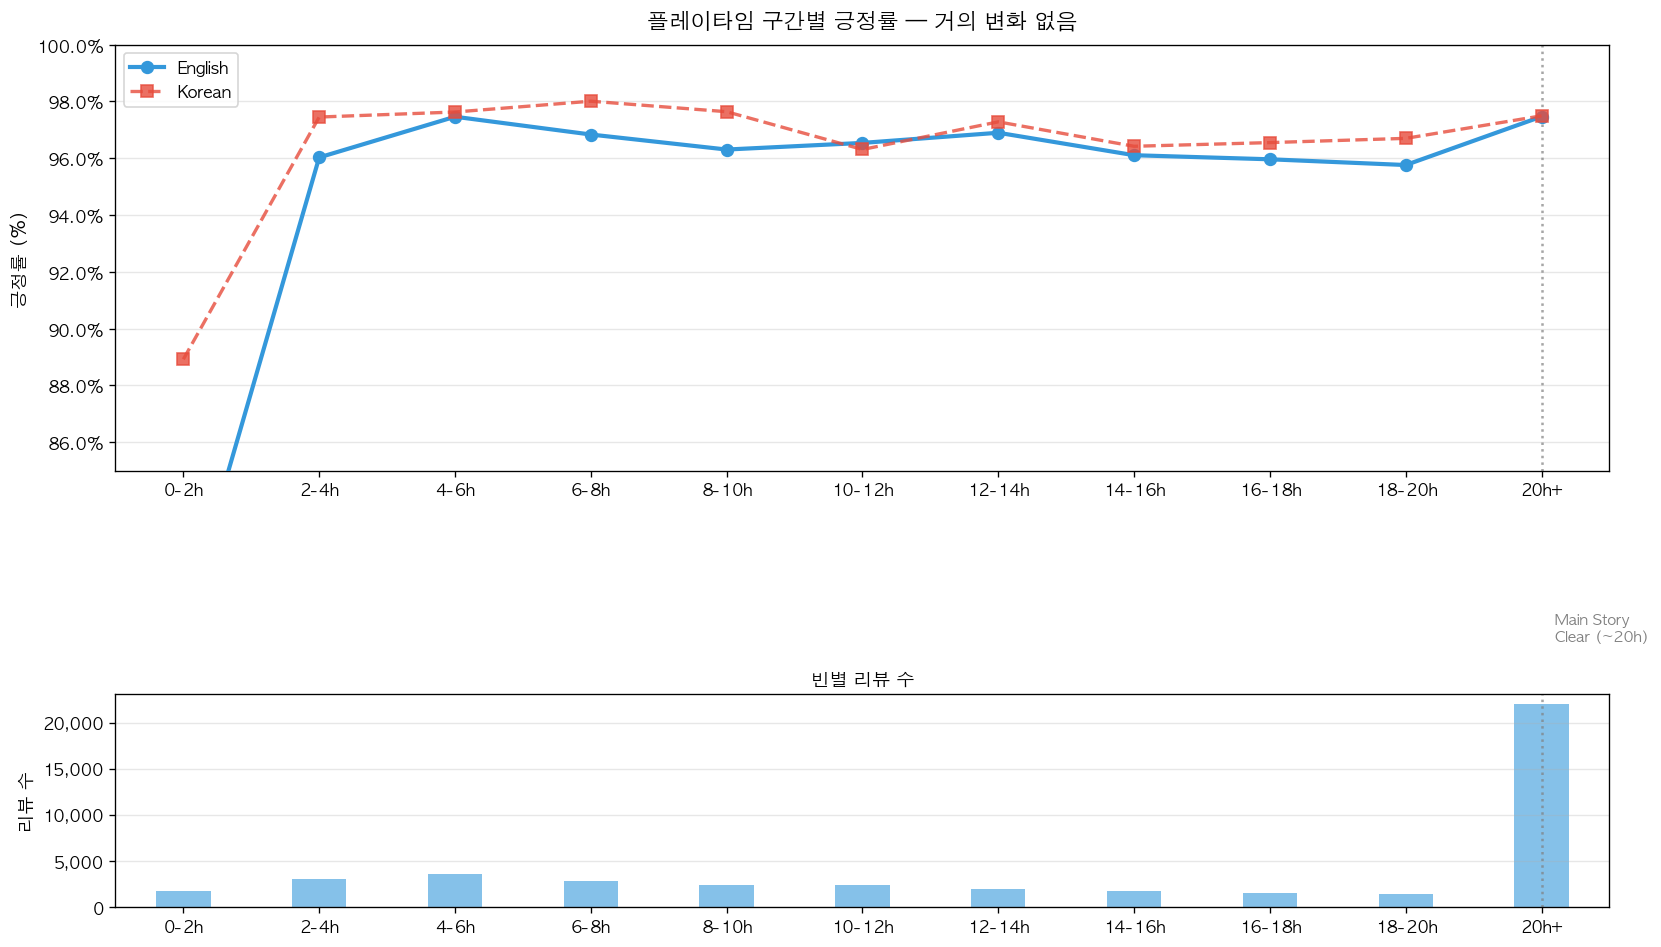

 저장: step1_positive_rate_by_bin.png


In [8]:
# STEP 1 시각화: 긍정률 라인 + 리뷰수 바
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 긍정률 라인
ax1 = axes[0]
x_en = range(len(rate_en))
ax1.plot(x_en, rate_en['pos_rate'], 'o-', color='#3498DB', linewidth=2.5,
         markersize=7, label='English', zorder=3)

# 한국어: 빈이 다를 수 있어 별도 처리
x_ko = np.linspace(0, len(rate_en)-1, len(rate_ko))
ax1.plot(x_ko, rate_ko['pos_rate'], 's--', color='#E74C3C', linewidth=2,
         markersize=7, alpha=0.8, label='Korean', zorder=3)

ax1.axvline(x=BIN_LABELS.index('20h+'), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.text(BIN_LABELS.index('20h+')+0.1, rate_en['pos_rate'].min()-0.5, 
         'Main Story\nClear (~20h)', fontsize=9, color='gray')

ax1.set_xlim(-0.5, len(rate_en)-0.5)
ax1.set_ylim(85, 100)
ax1.set_xticks(range(len(rate_en)))
ax1.set_xticklabels(rate_en.index.astype(str), fontsize=10)
ax1.set_ylabel('긍정률 (%)', fontsize=11)
ax1.set_title('플레이타임 구간별 긍정률 — 거의 변화 없음', fontsize=13, fontweight='bold', pad=10)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

# 하단: 리뷰 수 바
ax2 = axes[1]
bars_en = ax2.bar(x_en, rate_en['total'], color='#3498DB', alpha=0.6, label='English', width=0.4, align='center')

ax2.set_xlim(-0.5, len(rate_en)-0.5)
ax2.set_xticks(range(len(rate_en)))
ax2.set_xticklabels(rate_en.index.astype(str), fontsize=10)
ax2.set_ylabel('리뷰 수', fontsize=11)
ax2.set_title('빈별 리뷰 수', fontsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax2.axvline(x=BIN_LABELS.index('20h+'), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/step1_positive_rate_by_bin.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step1_positive_rate_by_bin.png')

> **해석**  
> 긍정률은 전 구간에서 거의 변화가 없다.  
> 따라서 "무엇을 칭찬/비판하는가"의 **내용 변화**를 분석해야 한다.

---
## STEP 2. [전문 데이터] LDA 토픽 구성비 변화 — 영어

> **목적**: 44,839건 전문 데이터의 LDA 토픽이 플레이타임에 따라 어떻게 변하는지 확인.

In [9]:
# 토픽 컬러맵 생성
import matplotlib.cm as cm

topic_labels_en = full_en['topic_label'].dropna().unique()
topic_labels_en_sorted = sorted(topic_labels_en)
n_topics = len(topic_labels_en_sorted)

cmap = cm.get_cmap('tab10', n_topics)
TOPIC_COLORS = {label: cmap(i) for i, label in enumerate(topic_labels_en_sorted)}

print(f'토픽 수: {n_topics}')
print(topic_labels_en_sorted)

토픽 수: 6
['Topic 0 게임 전반적인 평가', 'Topic 1 출시 직후 평가', 'Topic 2 감성/아트/분위기', 'Topic 3 낚시/잠수', 'Topic 4 게임플레이 루프', 'Topic 5 타 게임사와 비교']


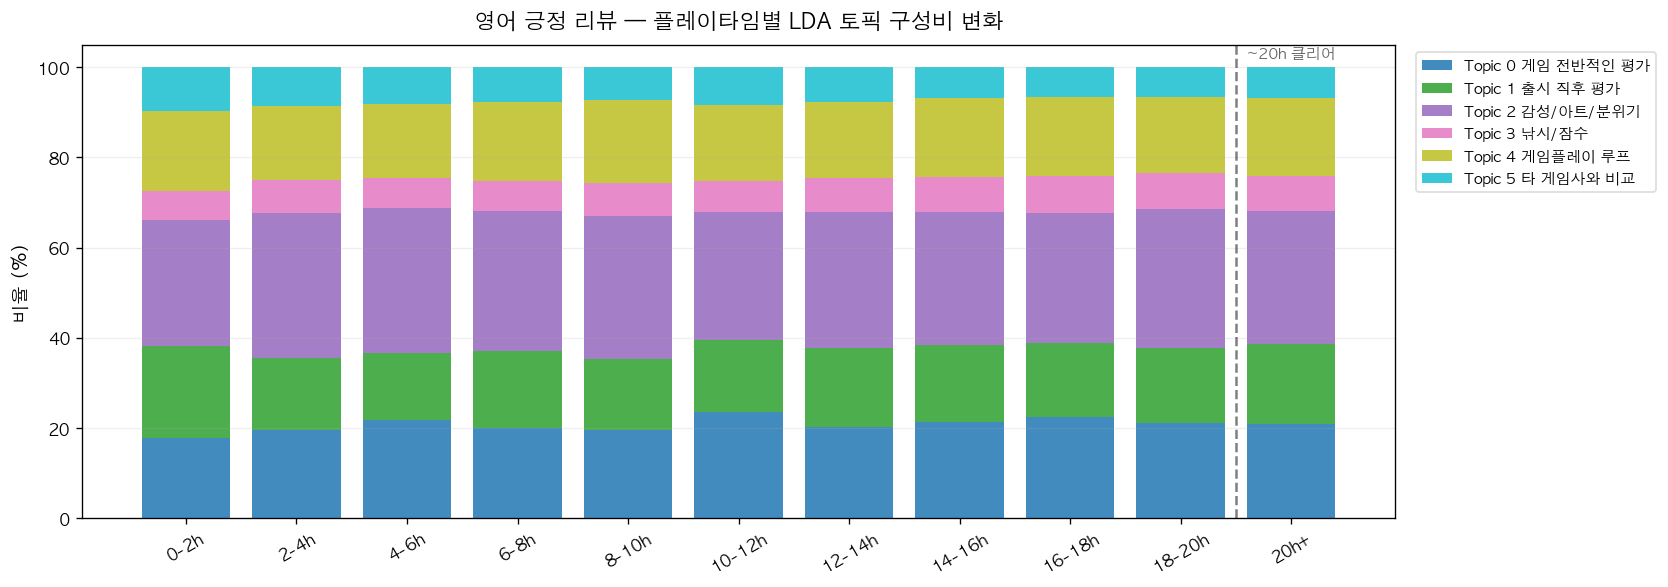

In [10]:
# 영어 긍정/부정 분리
full_en_pos = full_en[full_en['voted_up'] == 1].copy()
full_en_neg = full_en[full_en['voted_up'] == 0].copy()

def plot_topic_stacked_area(df, bin_col, title, figsize=(14, 5)):
    """100% Stacked Area 차트 — LDA 토픽 구성비"""
    # topic_label이 NaN인 행 제거
    df_valid = df[df['topic_label'].notna()]
    
    topic_comp = df_valid.groupby([bin_col, 'topic_label'], observed=True).size().unstack(fill_value=0)
    topic_comp_pct = topic_comp.div(topic_comp.sum(axis=1), axis=0) * 100
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = range(len(topic_comp_pct))
    bottom = np.zeros(len(topic_comp_pct))
    
    for col in topic_comp_pct.columns:
        color = TOPIC_COLORS.get(col, '#CCCCCC')
        ax.bar(x, topic_comp_pct[col].values, bottom=bottom,
               color=color, label=col, alpha=0.85, width=0.8)
        bottom += topic_comp_pct[col].values
    
    # 20h 클리어 기준선
    clear_idx = list(topic_comp_pct.index.astype(str)).index('20h+') if '20h+' in topic_comp_pct.index.astype(str) else None
    if clear_idx:
        ax.axvline(x=clear_idx - 0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
        ax.text(clear_idx - 0.4, 102, '~20h 클리어', fontsize=9, color='black', alpha=0.6)
    
    ax.set_xticks(x)
    ax.set_xticklabels(topic_comp_pct.index.astype(str), rotation=30, fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_ylabel('비율 (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.7)
    ax.grid(axis='y', alpha=0.2)
    
    plt.tight_layout()
    return fig, topic_comp_pct

# 영어 긍정 LDA 토픽 구성비
fig2a, topic_comp_en_pos_pct = plot_topic_stacked_area(
    full_en_pos, 'hour_bin_2h',
    '영어 긍정 리뷰 — 플레이타임별 LDA 토픽 구성비 변화'
)
plt.savefig('../reports/figures/step2a_lda_topic_en_pos.png', dpi=150, bbox_inches='tight')
plt.show()

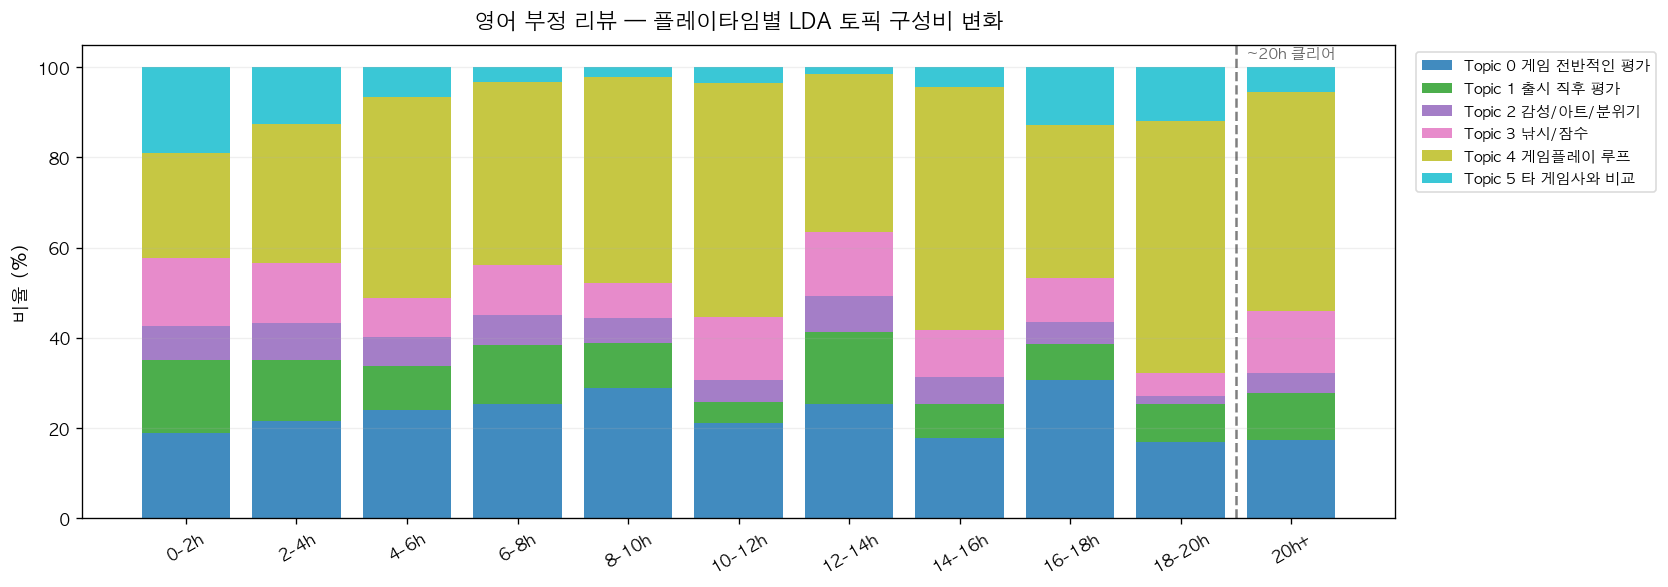

 LDA 토픽 차트 저장 완료


In [11]:
# 영어 부정 LDA 토픽 구성비
fig2b, topic_comp_en_neg_pct = plot_topic_stacked_area(
    full_en_neg, 'hour_bin_2h',
    '영어 부정 리뷰 — 플레이타임별 LDA 토픽 구성비 변화'
)
plt.savefig('../reports/figures/step2b_lda_topic_en_neg.png', dpi=150, bbox_inches='tight')
plt.show()
print(' LDA 토픽 차트 저장 완료')

**해석 포인트**
- 어떤 토픽이 줄고 어떤 토픽이 커지는가를 관찰
- LDA 토픽은 키워드 기반이라 해석에 한계 있음 → Step 4의 LLM aspect와 교차 확인

---
## STEP 3. [전문 데이터] 구간별 키워드 분석 — 플레이타임별 의견 변화

> **목적**: 플레이타임 구간마다 유저가 무엇을 이야기하고, 어느 시점에서 의견이 달라지는지 파악.
>
> - **3-1 TF-IDF 특징 키워드**: 해당 구간에서만 두드러지는 단어 (vs 나머지 구간 전체 비교) — 영어 긍정/부정  
> - **3-2 TF-IDF 히트맵**: 구간 × 키워드 강도 한눈에 파악 — 긍정/부정 2개  
> - **3-3 단순 빈도 비교**: 각 구간의 절대 Top 키워드 — 긍정 vs 부정  
> - **3-4 키워드 추이**: 주요 키워드의 구간별 등장률 변화선 — 의견 전환 포인트  
> - **3-5 한국어**: 동일 분석 (TF-IDF 특징 키워드 + 단순 빈도)

In [12]:

# STEP 3-1. TF-IDF 특징 키워드 함수 정의 + 영어 긍정/부정 출력
# "이 구간에서만 두드러지는 단어" = 해당 구간 TF-IDF 평균 - 나머지 구간 TF-IDF 평균

from collections import Counter
import re as _re

def extract_distinctive_keywords(df, bin_col, text_col, target_bin, n_keywords=15):
    """target_bin의 리뷰 vs 나머지 리뷰에서 TF-IDF 차이가 큰 키워드 추출"""
    target = df[df[bin_col].astype(str) == target_bin][text_col].dropna()
    others = df[df[bin_col].astype(str) != target_bin][text_col].dropna()
    if len(target) < 10:
        return []
    tfidf_v = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
    all_txt = pd.concat([target, others])
    tfidf_v.fit(all_txt)
    target_vec = tfidf_v.transform(target).mean(axis=0).A1
    others_vec = tfidf_v.transform(others).mean(axis=0).A1
    diff = target_vec - others_vec
    fn = tfidf_v.get_feature_names_out()
    top_idx = diff.argsort()[-n_keywords:][::-1]
    return [(fn[i], diff[i]) for i in top_idx]

def get_top_freq(df, bin_col, text_col, bins, top_n=12):
    """구간별 단순 토큰 빈도 Top N"""
    results = {}
    for b in bins:
        texts = df[df[bin_col].astype(str) == b][text_col].dropna()
        tokens = ' '.join(texts).split()
        results[b] = Counter(tokens).most_common(top_n)
    return results

TARGET_BINS = ['2-4h', '4-6h', '6-8h', '8-10h', '10-12h', '12-14h', '14-16h', '18-20h', '20h+']

# ── 영어 긍정 TF-IDF 특징 키워드 ──
print('=' * 78)
print(' 영어 긍정 — 구간별 TF-IDF 특징 키워드  (해당 구간에서만 두드러지는 단어)')
print('=' * 78)
keyword_results_en = {}
for bl in TARGET_BINS:
    kws = extract_distinctive_keywords(full_en_pos, 'hour_bin_2h', 'cleaned_text', bl)
    keyword_results_en[bl] = kws
    if kws:
        s = '  ·  '.join([f'{kw}({sc:.3f})' for kw, sc in kws[:8]])
        print(f'[{bl:8s}]  {s}')

# ── 영어 부정 TF-IDF 특징 키워드 ──
print()
print('=' * 78)
print(' 영어 부정 — 구간별 TF-IDF 특징 키워드')
print('=' * 78)
keyword_results_en_neg = {}
for bl in TARGET_BINS:
    kws = extract_distinctive_keywords(full_en_neg, 'hour_bin_2h', 'cleaned_text', bl)
    keyword_results_en_neg[bl] = kws
    if kws:
        s = '  ·  '.join([f'{kw}({sc:.3f})' for kw, sc in kws[:8]])
        print(f'[{bl:8s}]  {s}')


 영어 긍정 — 구간별 TF-IDF 특징 키워드  (해당 구간에서만 두드러지는 단어)
[2-4h    ]  fun(0.010)  ·  addict(0.005)  ·  far(0.004)  ·  chill(0.004)  ·  dive(0.003)  ·  buy(0.003)  ·  sushi(0.003)  ·  fun chill(0.003)
[4-6h    ]  fun(0.020)  ·  addictive(0.005)  ·  chill(0.004)  ·  far(0.004)  ·  fish(0.004)  ·  cool(0.004)  ·  addict(0.003)  ·  vibe(0.002)
[6-8h    ]  fun(0.006)  ·  amazing(0.004)  ·  funny(0.003)  ·  dive(0.003)  ·  far(0.003)  ·  chill(0.002)  ·  cutscene(0.002)  ·  fish(0.002)
[8-10h   ]  fish(0.007)  ·  chill(0.004)  ·  relax(0.003)  ·  fun(0.003)  ·  addict(0.003)  ·  indie(0.003)  ·  addictive(0.002)  ·  fire(0.002)
[10-12h  ]  fun(0.013)  ·  fish(0.004)  ·  diving(0.004)  ·  addictive(0.003)  ·  early access(0.003)  ·  access(0.003)  ·  release(0.003)  ·  dive(0.002)
[12-14h  ]  relax(0.005)  ·  amazing(0.004)  ·  release(0.004)  ·  access(0.003)  ·  early access(0.003)  ·  early(0.003)  ·  wait(0.003)  ·  love(0.003)
[14-16h  ]  fish(0.006)  ·  give(0.005)  ·  early(0.004)  ·  access(0.0

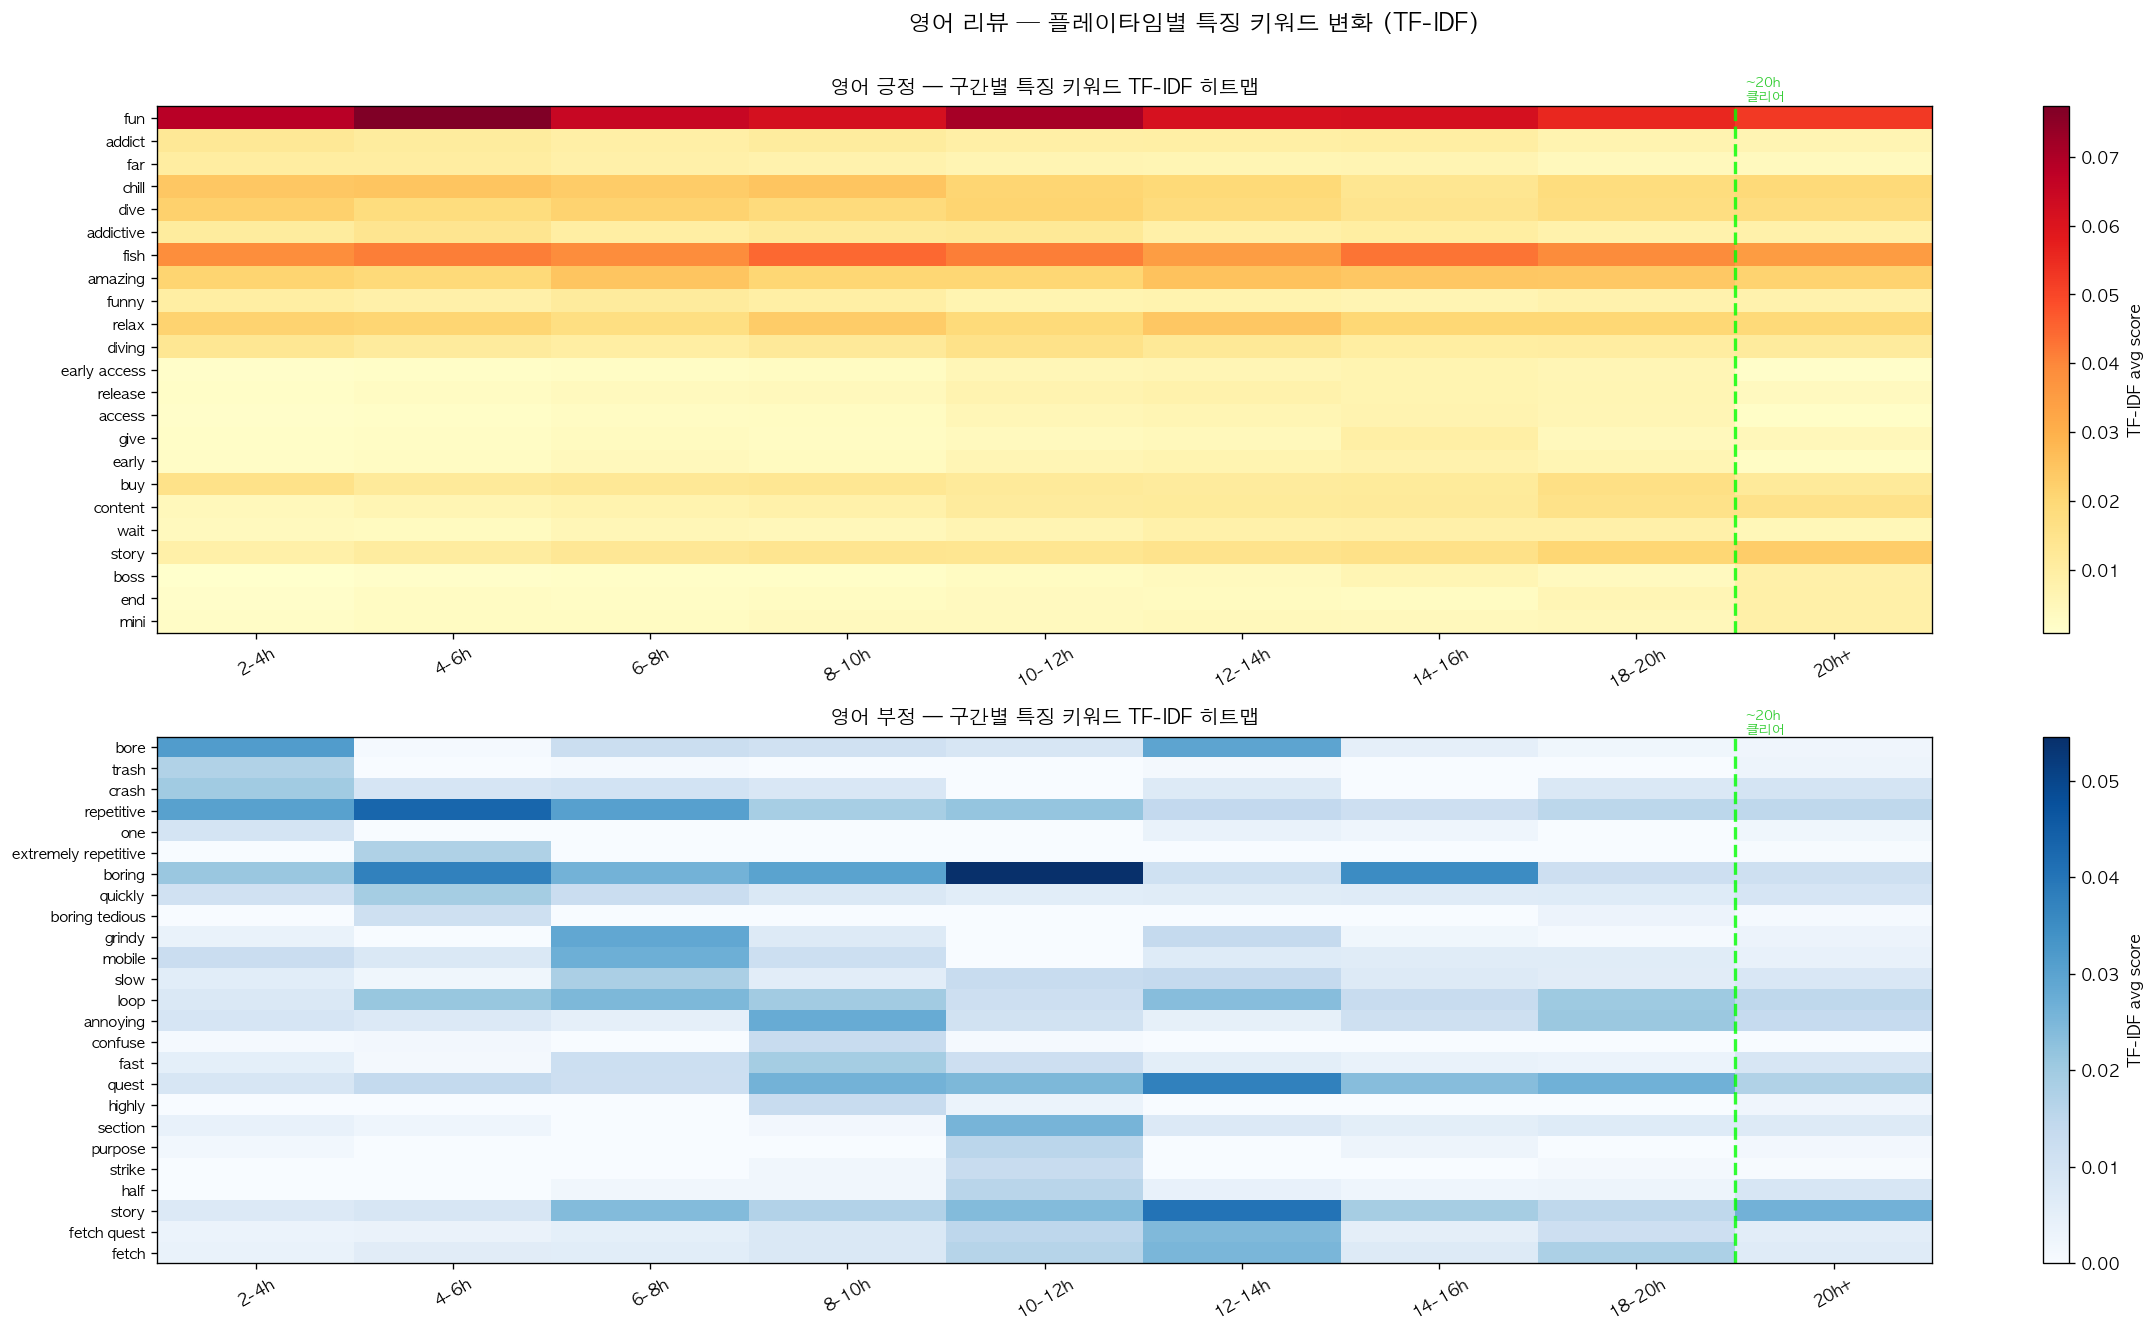

 저장: step3_tfidf_heatmap_en.png


In [13]:

# STEP 3-2. TF-IDF 히트맵 — 영어 긍정/부정 2개 나란히

def build_tfidf_heatmap_df(df, bin_col, text_col, bins, kw_results, top_per_bin=5, max_kw=25):
    """히트맵용 TF-IDF 행렬 구성 (각 구간의 특징 키워드 합집합 기준)"""
    kw_list = []
    for b in bins:
        for kw, _ in kw_results.get(b, [])[:top_per_bin]:
            if kw not in kw_list:
                kw_list.append(kw)
        if len(kw_list) >= max_kw:
            break
    kw_list = kw_list[:max_kw]
    if not kw_list:
        return pd.DataFrame()
    tg = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
    tg.fit(df[text_col].dropna())
    fn = tg.get_feature_names_out()
    fi = {f: i for i, f in enumerate(fn)}
    rows = []
    for b in bins:
        texts = df[df[bin_col].astype(str) == b][text_col].dropna()
        if len(texts) == 0:
            rows.append({kw: 0 for kw in kw_list})
        else:
            vec = tg.transform(texts).mean(axis=0).A1
            rows.append({kw: vec[fi[kw]] if kw in fi else 0 for kw in kw_list})
    return pd.DataFrame(rows, index=bins)[kw_list]

hm_pos = build_tfidf_heatmap_df(full_en_pos, 'hour_bin_2h', 'cleaned_text', TARGET_BINS, keyword_results_en)
hm_neg = build_tfidf_heatmap_df(full_en_neg, 'hour_bin_2h', 'cleaned_text', TARGET_BINS, keyword_results_en_neg)

fig, axes = plt.subplots(2, 1, figsize=(20, 11))
for ax, hm_df, title, cmap in [
    (axes[0], hm_pos, '영어 긍정 — 구간별 특징 키워드 TF-IDF 히트맵', 'YlOrRd'),
    (axes[1], hm_neg, '영어 부정 — 구간별 특징 키워드 TF-IDF 히트맵', 'Blues'),
]:
    if hm_df.empty:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=14)
        continue
    im = ax.imshow(hm_df.T.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(hm_df)))
    ax.set_xticklabels(list(hm_df.index), rotation=30, fontsize=10)
    ax.set_yticks(range(len(hm_df.columns)))
    ax.set_yticklabels(list(hm_df.columns), fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    plt.colorbar(im, ax=ax, label='TF-IDF avg score')
    bins_list = list(hm_df.index)
    if '20h+' in bins_list:
        ci = bins_list.index('20h+')
        ax.axvline(x=ci - 0.5, color='lime', linewidth=2, alpha=0.8, linestyle='--')
        ax.text(ci - 0.45, -1.8, '~20h\n클리어', fontsize=8, color='limegreen', va='top', fontweight='bold')

plt.suptitle('영어 리뷰 — 플레이타임별 특징 키워드 변화 (TF-IDF)', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('../reports/figures/step3_tfidf_heatmap_en.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step3_tfidf_heatmap_en.png')


In [14]:

# STEP 3-3. 구간별 단순 빈도 Top 키워드 — 긍정/부정 대비 출력
# (TF-IDF와 달리, 모든 구간에 공통적으로 많은 단어도 포함 → 절대적 관심 주제 파악)

pos_freq_en = get_top_freq(full_en_pos, 'hour_bin_2h', 'cleaned_text', TARGET_BINS, top_n=12)
neg_freq_en = get_top_freq(full_en_neg, 'hour_bin_2h', 'cleaned_text', TARGET_BINS, top_n=12)

print('=' * 78)
print(' 영어 — 구간별 단순 빈도 Top 키워드 비교 (긍정 vs 부정)')
print(' ※ 단순 등장 횟수 기준 — 공통 단어도 포함 (TF-IDF 특징 키워드와 비교 활용)')
print('=' * 78)

for bl in TARGET_BINS:
    pos_n = len(full_en_pos[full_en_pos['hour_bin_2h'].astype(str) == bl])
    neg_n = len(full_en_neg[full_en_neg['hour_bin_2h'].astype(str) == bl])
    if pos_n < 5 and neg_n < 5:
        continue
    print(f'\n[{bl}]  긍정 {pos_n:,}건 / 부정 {neg_n:,}건')
    pos_kws = '  '.join([f'{w}({c})' for w, c in pos_freq_en.get(bl, [])[:10]])
    neg_kws = '  '.join([f'{w}({c})' for w, c in neg_freq_en.get(bl, [])[:10]])
    print(f'  긍+ {pos_kws}')
    print(f'  부- {neg_kws}')


 영어 — 구간별 단순 빈도 Top 키워드 비교 (긍정 vs 부정)
 ※ 단순 등장 횟수 기준 — 공통 단어도 포함 (TF-IDF 특징 키워드와 비교 활용)

[2-4h]  긍정 2,902건 / 부정 120건
  긍+ fish(966)  fun(816)  love(438)  sushi(278)  gameplay(277)  restaurant(217)  relax(207)  dive(200)  story(195)  chill(189)
  부- fun(47)  fish(40)  gameplay(29)  restaurant(26)  run(23)  mechanic(22)  dive(21)  people(20)  experience(16)  find(16)

[4-6h]  긍정 3,533건 / 부정 92건
  긍+ fun(1040)  love(578)  fish(490)  gameplay(330)  sushi(280)  restaurant(270)  story(267)  chill(231)  dive(225)  relax(225)
  부- gameplay(34)  fish(34)  fun(32)  restaurant(27)  boring(25)  mechanic(21)  repetitive(21)  dive(21)  diving(20)  loop(18)

[6-8h]  긍정 2,785건 / 부정 91건
  긍+ fun(771)  love(382)  fish(369)  story(259)  gameplay(249)  restaurant(225)  sushi(213)  amazing(207)  dive(191)  chill(181)
  부- fish(36)  fun(30)  story(26)  dive(25)  restaurant(25)  gameplay(25)  loop(21)  diving(21)  find(19)  day(19)

[8-10h]  긍정 2,347건 / 부정 90건
  긍+ fun(619)  fish(409)  love(305)  story(246) 

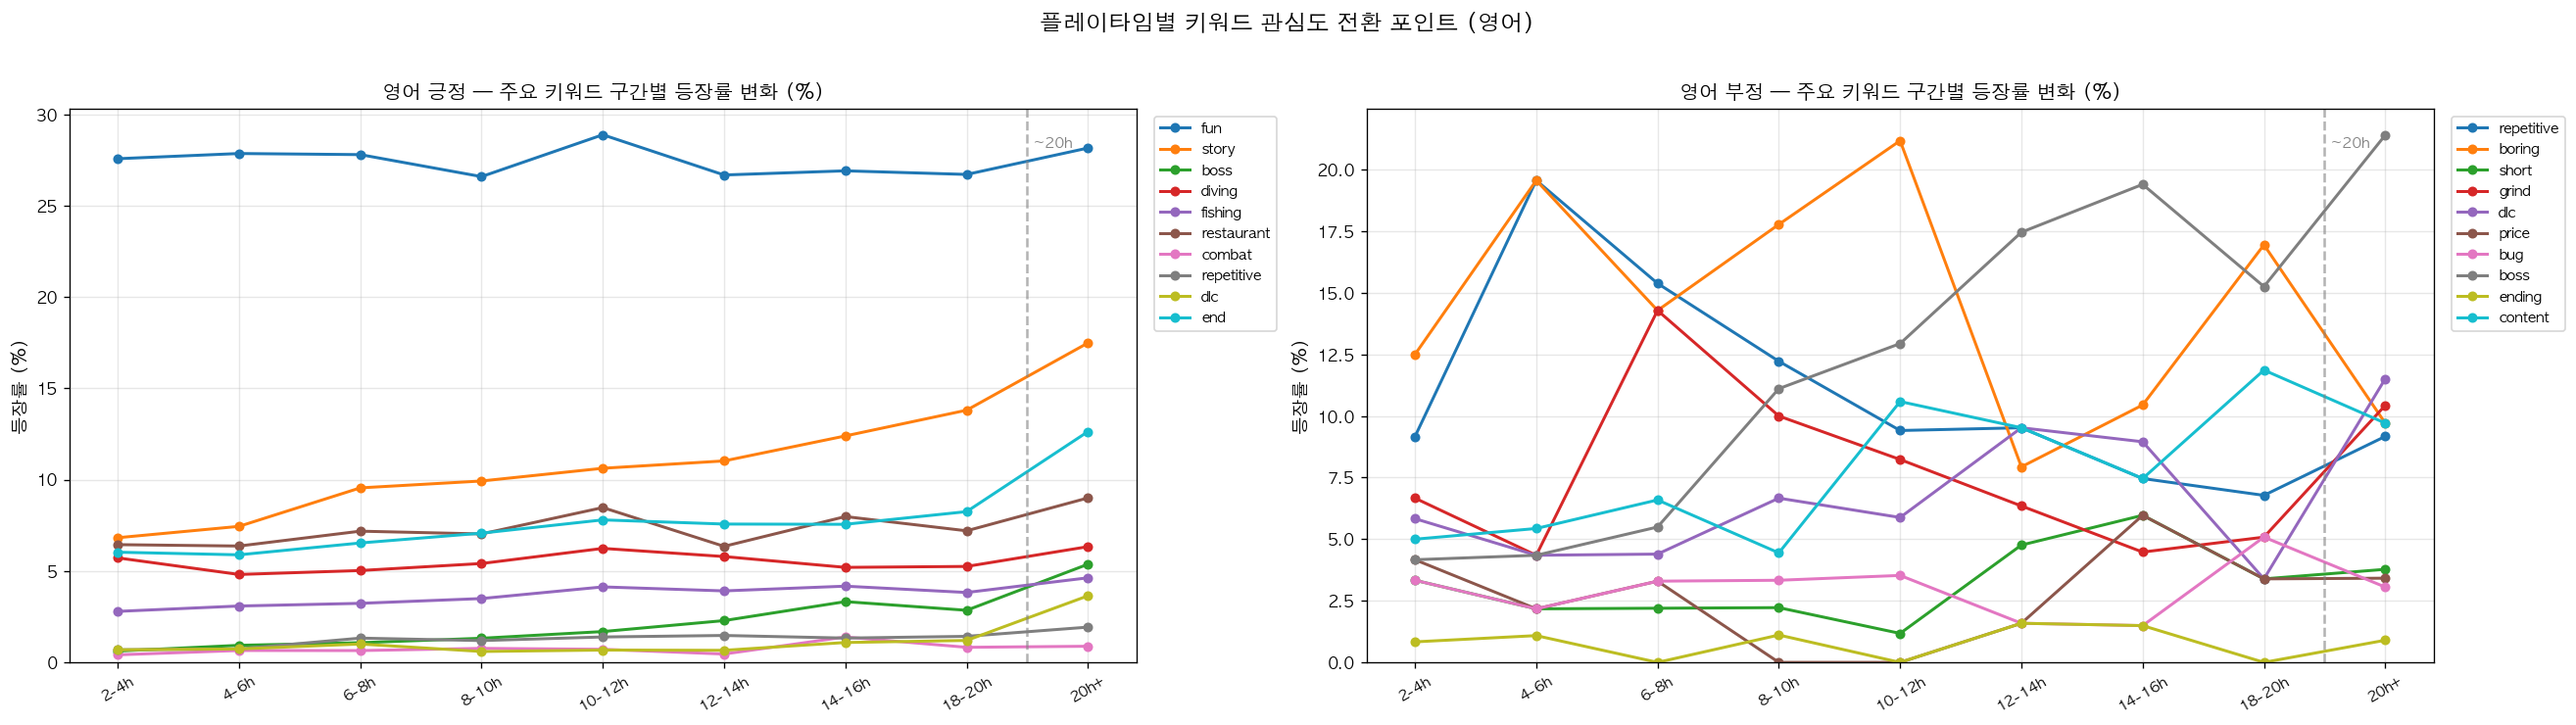

 저장: step3_keyword_trend_en.png


In [15]:

# STEP 3-4. 주요 키워드 구간별 등장률 추이 — 의견 전환 포인트 시각화
# 특정 키워드가 어느 구간에서 급증/급감하는지 라인 차트로 확인

import re as _re2

def keyword_mention_rate(df, bin_col, text_col, bins, keywords):
    """키워드별 구간별 등장률 (해당 구간 리뷰 중 키워드 포함 비율 %)"""
    result = {}
    for kw in keywords:
        rates = []
        for b in bins:
            texts = df[df[bin_col].astype(str) == b][text_col].dropna()
            n = len(texts)
            if n == 0:
                rates.append(0.0)
            else:
                cnt = texts.str.contains(_re2.escape(kw), regex=True, case=False).sum()
                rates.append(cnt / n * 100)
        result[kw] = rates
    return result

# 관심 키워드 목록 (각 구간에서 의미 있게 변할 법한 것들)
WATCH_POS = ['fun', 'story', 'boss', 'diving', 'fishing', 'restaurant', 'combat', 'repetitive', 'dlc', 'end']
WATCH_NEG = ['repetitive', 'boring', 'short', 'grind', 'dlc', 'price', 'bug', 'boss', 'ending', 'content']

pos_trend = keyword_mention_rate(full_en_pos, 'hour_bin_2h', 'cleaned_text', TARGET_BINS, WATCH_POS)
neg_trend = keyword_mention_rate(full_en_neg, 'hour_bin_2h', 'cleaned_text', TARGET_BINS, WATCH_NEG)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
for ax, trend, keywords, title in [
    (axes[0], pos_trend, WATCH_POS, '영어 긍정 — 주요 키워드 구간별 등장률 변화 (%)'),
    (axes[1], neg_trend, WATCH_NEG, '영어 부정 — 주요 키워드 구간별 등장률 변화 (%)'),
]:
    cmap = plt.get_cmap('tab10')
    x = range(len(TARGET_BINS))
    for idx, kw in enumerate(keywords):
        vals = trend[kw]
        if max(vals) < 0.3:
            continue
        ax.plot(x, vals, 'o-', label=kw, color=cmap(idx % 10), linewidth=1.8, markersize=5)

    if '20h+' in TARGET_BINS:
        ci = TARGET_BINS.index('20h+')
        ax.axvline(x=ci - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5
        ax.text(ci - 0.45, ymax * 0.93, '~20h', fontsize=9, color='gray')

    ax.set_xticks(range(len(TARGET_BINS)))
    ax.set_xticklabels(TARGET_BINS, rotation=30, fontsize=9)
    ax.set_ylabel('등장률 (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('플레이타임별 키워드 관심도 전환 포인트 (영어)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/step3_keyword_trend_en.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step3_keyword_trend_en.png')


In [16]:

# STEP 3-5. 한국어 — TF-IDF 특징 키워드 + 단순 빈도
full_ko_pos = full_ko[full_ko['voted_up'] == 1].copy()
full_ko_neg = full_ko[full_ko['voted_up'] == 0].copy()

ko_bins = sorted([str(b) for b in full_ko_pos[KO_BIN_COL].dropna().unique()])
keyword_results_ko = {}
keyword_results_ko_neg = {}

# ── 한국어 긍정 TF-IDF 특징 키워드 ──
print('=' * 78)
print(' 한국어 긍정 — 구간별 TF-IDF 특징 키워드')
print('=' * 78)
for b in ko_bins:
    kws = extract_distinctive_keywords(full_ko_pos, KO_BIN_COL, 'cleaned_text', b)
    keyword_results_ko[b] = kws
    if kws:
        s = '  ·  '.join([f'{kw}({sc:.3f})' for kw, sc in kws[:8]])
        print(f'[{b:8s}]  {s}')

# ── 한국어 부정 TF-IDF 특징 키워드 ──
print()
print('=' * 78)
print(' 한국어 부정 — 구간별 TF-IDF 특징 키워드')
print('=' * 78)
for b in ko_bins:
    kws = extract_distinctive_keywords(full_ko_neg, KO_BIN_COL, 'cleaned_text', b)
    keyword_results_ko_neg[b] = kws
    if kws:
        s = '  ·  '.join([f'{kw}({sc:.3f})' for kw, sc in kws[:8]])
        print(f'[{b:8s}]  {s}')

# ── 한국어 단순 빈도 Top 키워드 (긍정 vs 부정) ──
print()
print('=' * 78)
print(' 한국어 — 구간별 단순 빈도 Top 키워드 비교 (긍정 vs 부정)')
print('=' * 78)
pos_freq_ko = get_top_freq(full_ko_pos, KO_BIN_COL, 'cleaned_text', ko_bins, top_n=12)
neg_freq_ko = get_top_freq(full_ko_neg, KO_BIN_COL, 'cleaned_text', ko_bins, top_n=12)

for b in ko_bins:
    pos_n = len(full_ko_pos[full_ko_pos[KO_BIN_COL].astype(str) == b])
    neg_n = len(full_ko_neg[full_ko_neg[KO_BIN_COL].astype(str) == b])
    if pos_n < 3 and neg_n < 3:
        continue
    print(f'\n[{b}]  긍정 {pos_n:,}건 / 부정 {neg_n:,}건')
    pos_kws = '  '.join([f'{w}({c})' for w, c in pos_freq_ko.get(b, [])[:10]])
    neg_kws = '  '.join([f'{w}({c})' for w, c in neg_freq_ko.get(b, [])[:10]])
    print(f'  긍+ {pos_kws}')
    print(f'  부- {neg_kws}')


 한국어 긍정 — 구간별 TF-IDF 특징 키워드
[0-2h    ]  넥슨(0.037)  ·  잠깐(0.011)  ·  니케(0.010)  ·  느끼(0.010)  ·  이제(0.009)  ·  지원(0.008)  ·  넥슨 만들(0.007)  ·  올해(0.006)
[10-12h  ]  재밌(0.009)  ·  정식(0.008)  ·  넥슨(0.006)  ·  재미(0.006)  ·  중독(0.006)  ·  존재(0.005)  ·  아기자기(0.004)  ·  재미있(0.004)
[12-14h  ]  재밌(0.010)  ·  정식(0.010)  ·  재미있(0.007)  ·  꿀잼(0.007)  ·  정식 출시(0.007)  ·  출시(0.006)  ·  존재(0.006)  ·  멈추(0.005)
[14-16h  ]  정식(0.015)  ·  출시(0.015)  ·  정식 출시(0.012)  ·  모르(0.009)  ·  빨리(0.009)  ·  컨텐츠(0.008)  ·  얼엑(0.007)  ·  언제(0.006)
[16-18h  ]  정식(0.025)  ·  정식 출시(0.013)  ·  출시(0.013)  ·  빨리(0.013)  ·  꿀잼(0.011)  ·  갓겜(0.011)  ·  빨리 정식(0.010)  ·  언제(0.008)
[18-20h  ]  정식(0.013)  ·  출시(0.012)  ·  존나(0.010)  ·  정식 출시(0.010)  ·  빨리 정식(0.008)  ·  불감증(0.007)  ·  기대(0.006)  ·  인생(0.006)
[2-4h    ]  재밌(0.025)  ·  넥슨(0.022)  ·  잠깐(0.007)  ·  중독(0.007)  ·  꿀잼(0.004)  ·  그래픽(0.004)  ·  오랜만(0.004)  ·  재미(0.004)
[20h+    ]  엔딩(0.014)  ·  스토리(0.009)  ·  즐기(0.008)  ·  컨텐츠(0.006)  ·  후반(0.005)  ·  최고(0.005)  ·  다양(0.

---
## STEP 4. [LLM 데이터] aspect/category 구성비 변화 — 영어

> **목적**: LLM이 분류한 의미 레이블(aspect/category)의 구성비가 플레이타임에 따라 어떻게 변하는지 확인.

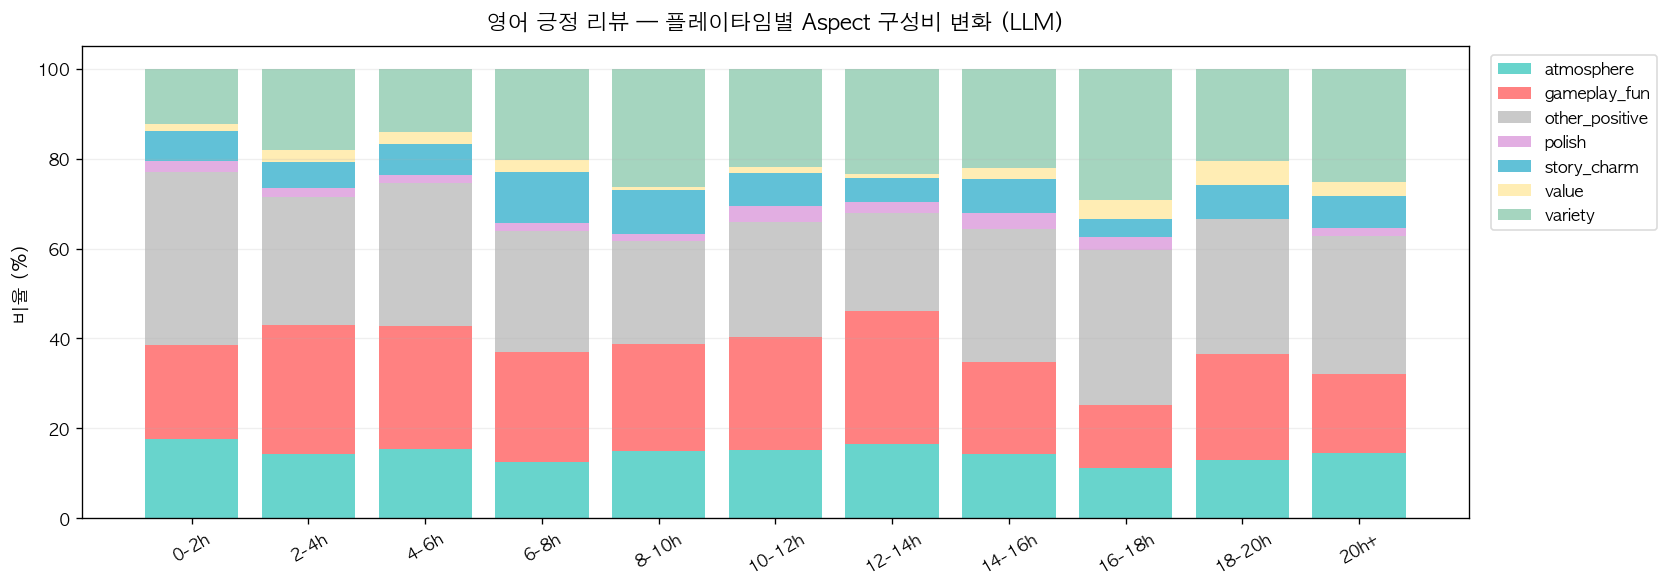

In [17]:
def plot_label_stacked_area(df, bin_col, label_col, color_dict, title, figsize=(14, 5)):
    """100% Stacked Area — LLM 레이블 구성비"""
    df_valid = df[df[label_col].notna() & df[bin_col].notna()]
    comp = df_valid.groupby([bin_col, label_col], observed=True).size().unstack(fill_value=0)
    comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100
    
    fig, ax = plt.subplots(figsize=figsize)
    x = range(len(comp_pct))
    bottom = np.zeros(len(comp_pct))
    
    for col in comp_pct.columns:
        color = color_dict.get(col, '#CCCCCC')
        ax.bar(x, comp_pct[col].values, bottom=bottom,
               color=color, label=col, alpha=0.85, width=0.8)
        bottom += comp_pct[col].values
    
    ax.set_xticks(x)
    ax.set_xticklabels(comp_pct.index.astype(str), rotation=30, fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_ylabel('비율 (%)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, framealpha=0.7)
    ax.grid(axis='y', alpha=0.2)
    
    plt.tight_layout()
    return fig, comp_pct

# 영어 긍정 — aspect 구성비
fig4a, aspect_comp_pct = plot_label_stacked_area(
    pos_en, EN_BIN_COL, 'aspect', ASPECT_COLORS,
    '영어 긍정 리뷰 — 플레이타임별 Aspect 구성비 변화 (LLM)'
)
plt.savefig('../reports/figures/step4a_aspect_en.png', dpi=150, bbox_inches='tight')
plt.show()

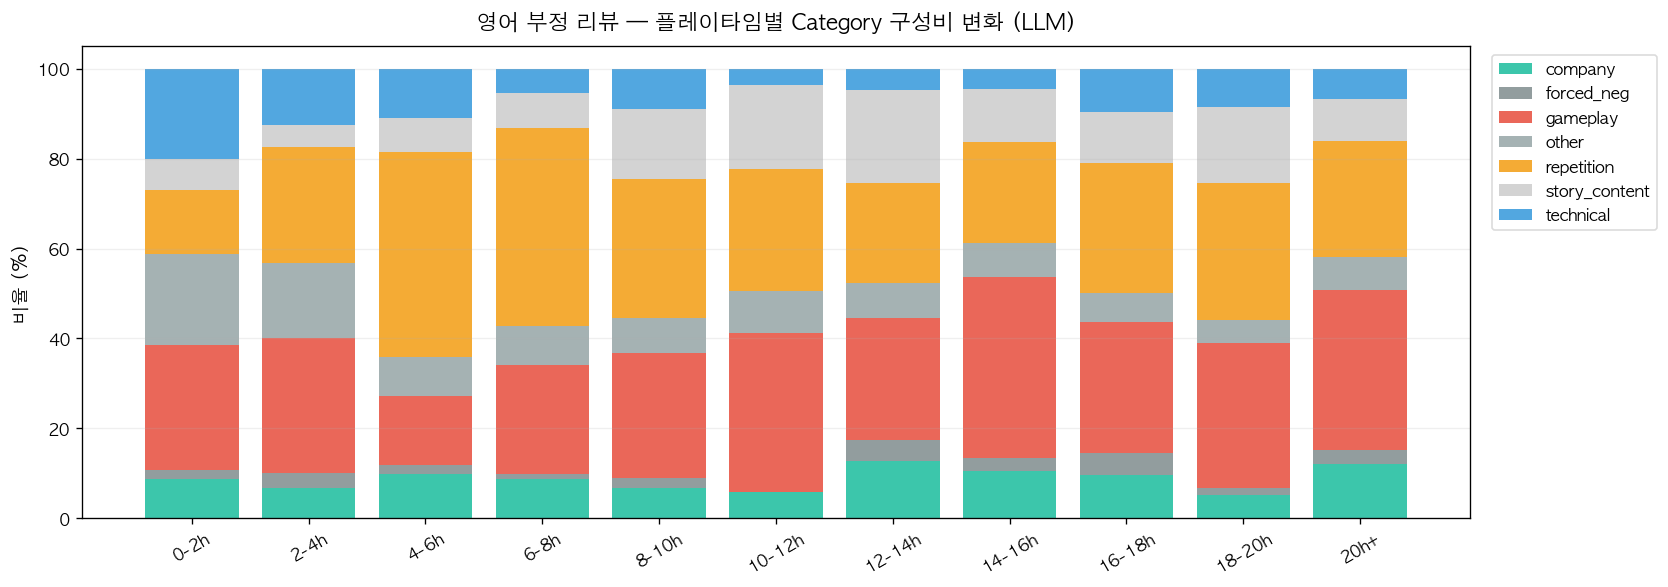

 Step 4 저장 완료


In [18]:
# 영어 부정 — category 구성비
fig4b, cat_comp_pct = plot_label_stacked_area(
    neg_en, EN_BIN_COL, 'category', CATEGORY_COLORS,
    '영어 부정 리뷰 — 플레이타임별 Category 구성비 변화 (LLM)'
)
plt.savefig('../reports/figures/step4b_category_en.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Step 4 저장 완료')

### 4-3. 교차 검증: LDA 토픽 vs LLM Aspect

| 분석 | 결과 |
|------|------|
| Step 2 LDA 변곡 지점 | (데이터 확인 후 기입) |
| Step 4 LLM aspect 변곡 지점 | (데이터 확인 후 기입) |
| 일치 여부 | ✅ 일치 / ⚠️ 불일치 (기입) |

> 일치하면: LDA와 LLM이 같은 현상을 포착 → 신뢰도 UP  
> 불일치하면: LDA는 키워드 기반이라 놓친 뉘앙스를 LLM이 잡았거나, 그 반대

---
## STEP 5. [LLM 데이터] 한국어 동일 분석

> **목적**: 한국어 유저의 패턴이 영어와 같은지/다른지 확인.

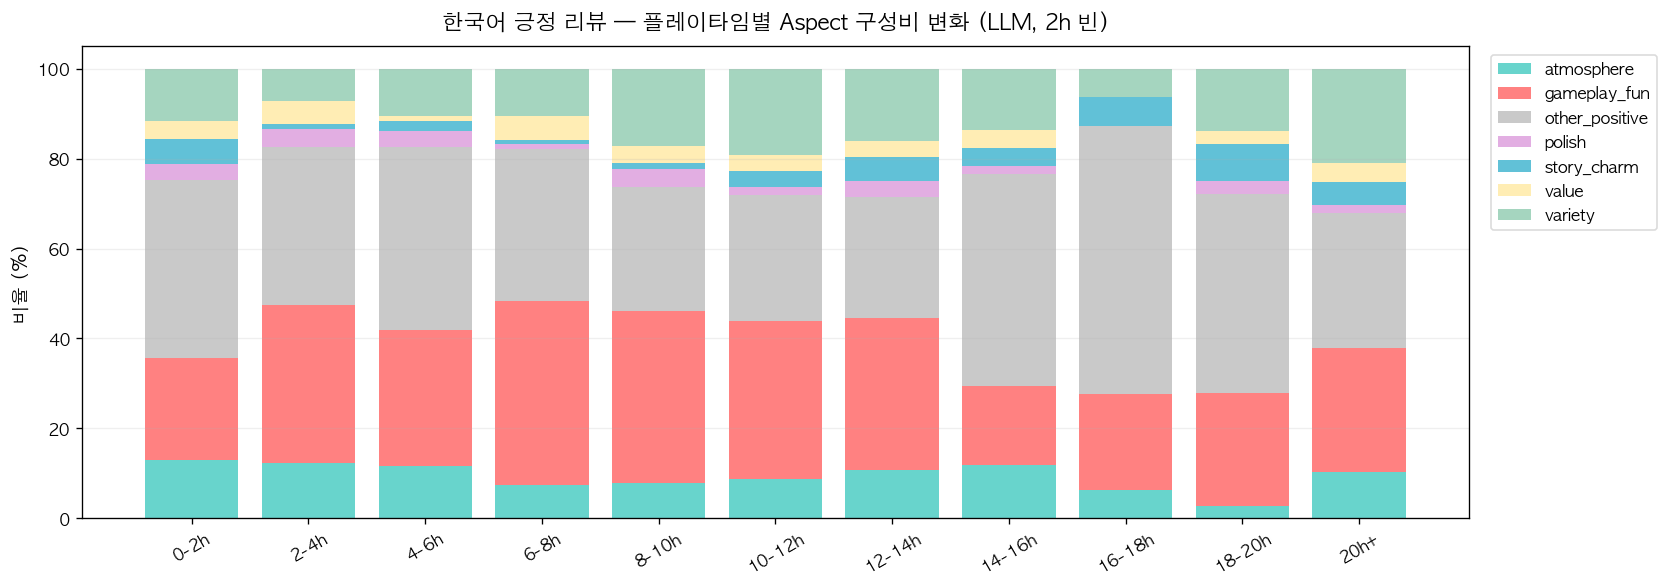

In [19]:
# 한국어 긍정 — aspect 구성비
fig5a, aspect_comp_ko_pct = plot_label_stacked_area(
    pos_ko, KO_BIN_COL, 'aspect', ASPECT_COLORS,
    f'한국어 긍정 리뷰 — 플레이타임별 Aspect 구성비 변화 (LLM, {KO_BIN_SIZE}h 빈)'
)
plt.savefig('../reports/figures/step5a_aspect_ko.png', dpi=150, bbox_inches='tight')
plt.show()

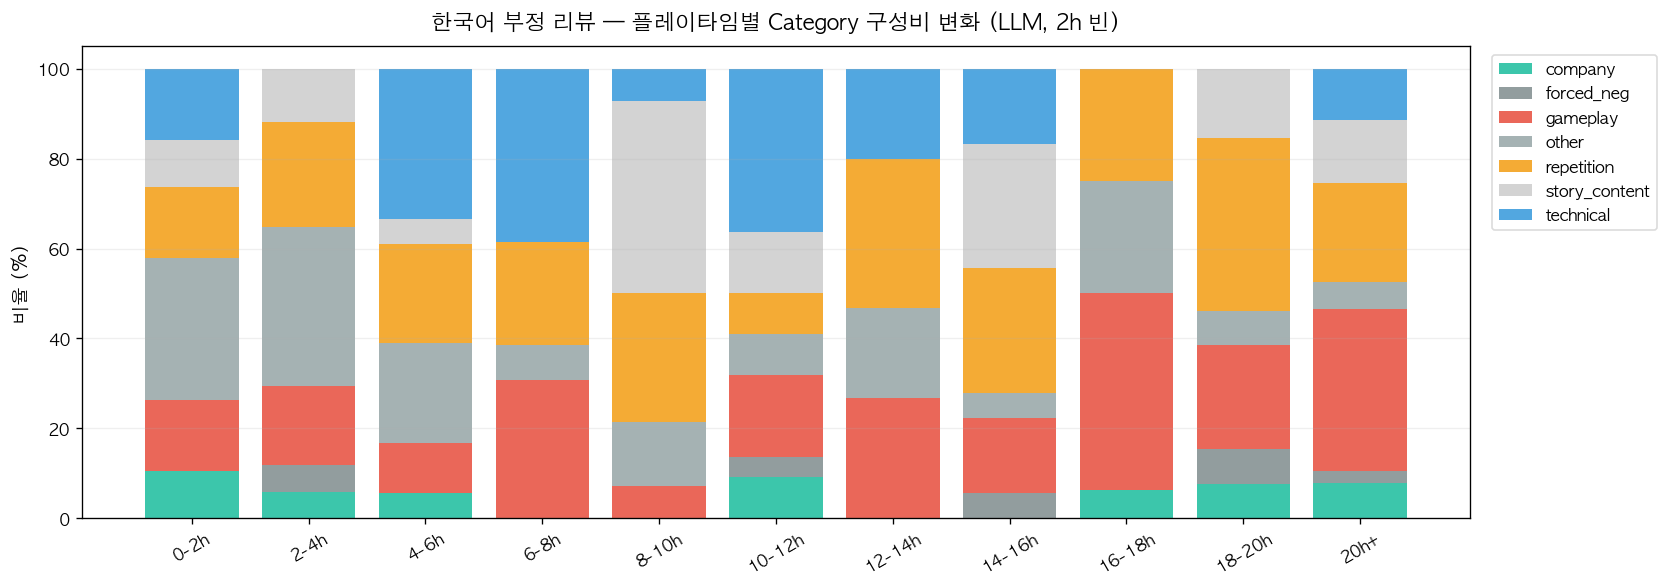

 Step 5 저장 완료


In [20]:
# 한국어 부정 — category 구성비
fig5b, cat_comp_ko_pct = plot_label_stacked_area(
    neg_ko, KO_BIN_COL, 'category', CATEGORY_COLORS,
    f'한국어 부정 리뷰 — 플레이타임별 Category 구성비 변화 (LLM, {KO_BIN_SIZE}h 빈)'
)
plt.savefig('../reports/figures/step5b_category_ko.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Step 5 저장 완료')

In [21]:
# 5-1. 한국어 14h+ other_positive 급등 원인 파악
TARGET_BIN = '14-16h'
N_SAMPLE = 10
np.random.seed(42)

ko_14h_other = pos_ko[
    (pos_ko[KO_BIN_COL] == TARGET_BIN) &
    (pos_ko['aspect'] == 'other_positive')
].copy() if 'aspect' in pos_ko.columns else pd.DataFrame()

print(f'[한국어 {TARGET_BIN} other_positive] 총 {len(ko_14h_other)}건')

if len(ko_14h_other) > 0:
    sample = ko_14h_other.sample(min(N_SAMPLE, len(ko_14h_other)), random_state=42)
    print('\n=== 리뷰 원문 샘플 ===')
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        pt = row.get('playtime_hours', float('nan'))
        text = str(row.get('review_text', ''))
        print(f'\n[{i}] {pt:.1f}h')
        print(text[:400] + ('...' if len(text) > 400 else ''))

# 동일 구간 영어와 aspect 비율 비교
print('\n=== 동일 구간 aspect 비율 비교 ===')
for lang_label, df_tgt, bin_col in [
    ('영어', pos_en, EN_BIN_COL),
    ('한국어', pos_ko, KO_BIN_COL)
]:
    seg = df_tgt[df_tgt[bin_col] == TARGET_BIN]
    if len(seg) > 0 and 'aspect' in seg.columns:
        dist = seg['aspect'].value_counts(normalize=True).mul(100).round(1)
        print(f'\n{lang_label} ({len(seg)}건):')
        for asp, pct in dist.items():
            print(f'  {asp}: {pct}%')

[한국어 14-16h other_positive] 총 24건

=== 리뷰 원문 샘플 ===

[1] 14.8h
pc에도 무적인 갓겜

[2] 15.4h
늑대장어 보스 등장 전에 버그가 자꾸 발생하네요. 데이브가 보스존에 입장후 혼잣말로 "여길 나보고 들어가라고??"이말 한 직후에 아무 컨트롤도 먹히지않습니다.

[3] 14.1h
갓겜

[4] 14.6h
뭔가 처음부터 끌리면 무조건 갓겜임

[5] 15.6h
당장 정식 출시 빨리 어서!!!!!!!!!!!!!!

[6] 15.5h
갓겜

[7] 15.8h
재미있어요 정식 출시 기다려지네요

[8] 15.8h
잘 만든 게임.

[9] 15.1h
매우 갓겜
힐링은 덤

[10] 15.4h
개꿀잼임 진짜


=== 동일 구간 aspect 비율 비교 ===

영어 (118건):
  other_positive: 29.7%
  variety: 22.0%
  gameplay_fun: 20.3%
  atmosphere: 14.4%
  story_charm: 7.6%
  polish: 3.4%
  value: 2.5%

한국어 (51건):
  other_positive: 47.1%
  gameplay_fun: 17.6%
  variety: 13.7%
  atmosphere: 11.8%
  story_charm: 3.9%
  value: 3.9%
  polish: 2.0%


---
## STEP 6. 변곡점 종합 + 구간 확정

> **목적**: Step 2~5의 모든 결과를 종합해서 최종 구간을 확정.

In [22]:
# 6-1. 정량적 변곡점 식별 — 인접 빈 간 코사인 유사도

def find_inflection_points(comp_pct, label='', threshold=0.95):
    bins_ordered = comp_pct.index.tolist()
    similarities = []
    for i in range(len(bins_ordered) - 1):
        v1 = comp_pct.iloc[i].values.reshape(1, -1)
        v2 = comp_pct.iloc[i+1].values.reshape(1, -1)
        sim = cosine_similarity(v1, v2)[0][0]
        similarities.append((str(bins_ordered[i]), str(bins_ordered[i+1]), sim))
    
    print(f'\n=== {label} ===')
    for b1, b2, sim in similarities:
        marker = ' ◀ 변곡점 후보' if sim < threshold else ''
        print(f'  {b1} → {b2}: {sim:.4f}{marker}')
    
    return similarities

sim_en_pos = find_inflection_points(aspect_comp_pct, '영어 긍정 (aspect)')
sim_en_neg = find_inflection_points(cat_comp_pct, '영어 부정 (category)')

if len(aspect_comp_ko_pct) > 1:
    sim_ko_pos = find_inflection_points(aspect_comp_ko_pct, '한국어 긍정 (aspect)')
if len(cat_comp_ko_pct) > 1:
    sim_ko_neg = find_inflection_points(cat_comp_ko_pct, '한국어 부정 (category)')


=== 영어 긍정 (aspect) ===
  0-2h → 2-4h: 0.9566
  2-4h → 4-6h: 0.9928
  4-6h → 6-8h: 0.9780
  6-8h → 8-10h: 0.9836
  8-10h → 10-12h: 0.9903
  10-12h → 12-14h: 0.9899
  12-14h → 14-16h: 0.9622
  14-16h → 16-18h: 0.9717
  16-18h → 18-20h: 0.9546
  18-20h → 20h+: 0.9836

=== 영어 부정 (category) ===
  0-2h → 2-4h: 0.9461 ◀ 변곡점 후보
  2-4h → 4-6h: 0.8602 ◀ 변곡점 후보
  4-6h → 6-8h: 0.9791
  6-8h → 8-10h: 0.9546
  8-10h → 10-12h: 0.9760
  10-12h → 12-14h: 0.9692
  12-14h → 14-16h: 0.9476 ◀ 변곡점 후보
  14-16h → 16-18h: 0.9587
  16-18h → 18-20h: 0.9848
  18-20h → 20h+: 0.9679

=== 한국어 긍정 (aspect) ===
  0-2h → 2-4h: 0.9589
  2-4h → 4-6h: 0.9851
  4-6h → 6-8h: 0.9648
  6-8h → 8-10h: 0.9850
  8-10h → 10-12h: 0.9953
  10-12h → 12-14h: 0.9959
  12-14h → 14-16h: 0.8731 ◀ 변곡점 후보
  14-16h → 16-18h: 0.9757
  16-18h → 18-20h: 0.9680
  18-20h → 20h+: 0.9419 ◀ 변곡점 후보

=== 한국어 부정 (category) ===
  0-2h → 2-4h: 0.9134 ◀ 변곡점 후보
  2-4h → 4-6h: 0.6959 ◀ 변곡점 후보
  4-6h → 6-8h: 0.8790 ◀ 변곡점 후보
  6-8h → 8-10h: 0.4229 ◀ 변곡점 후보
  

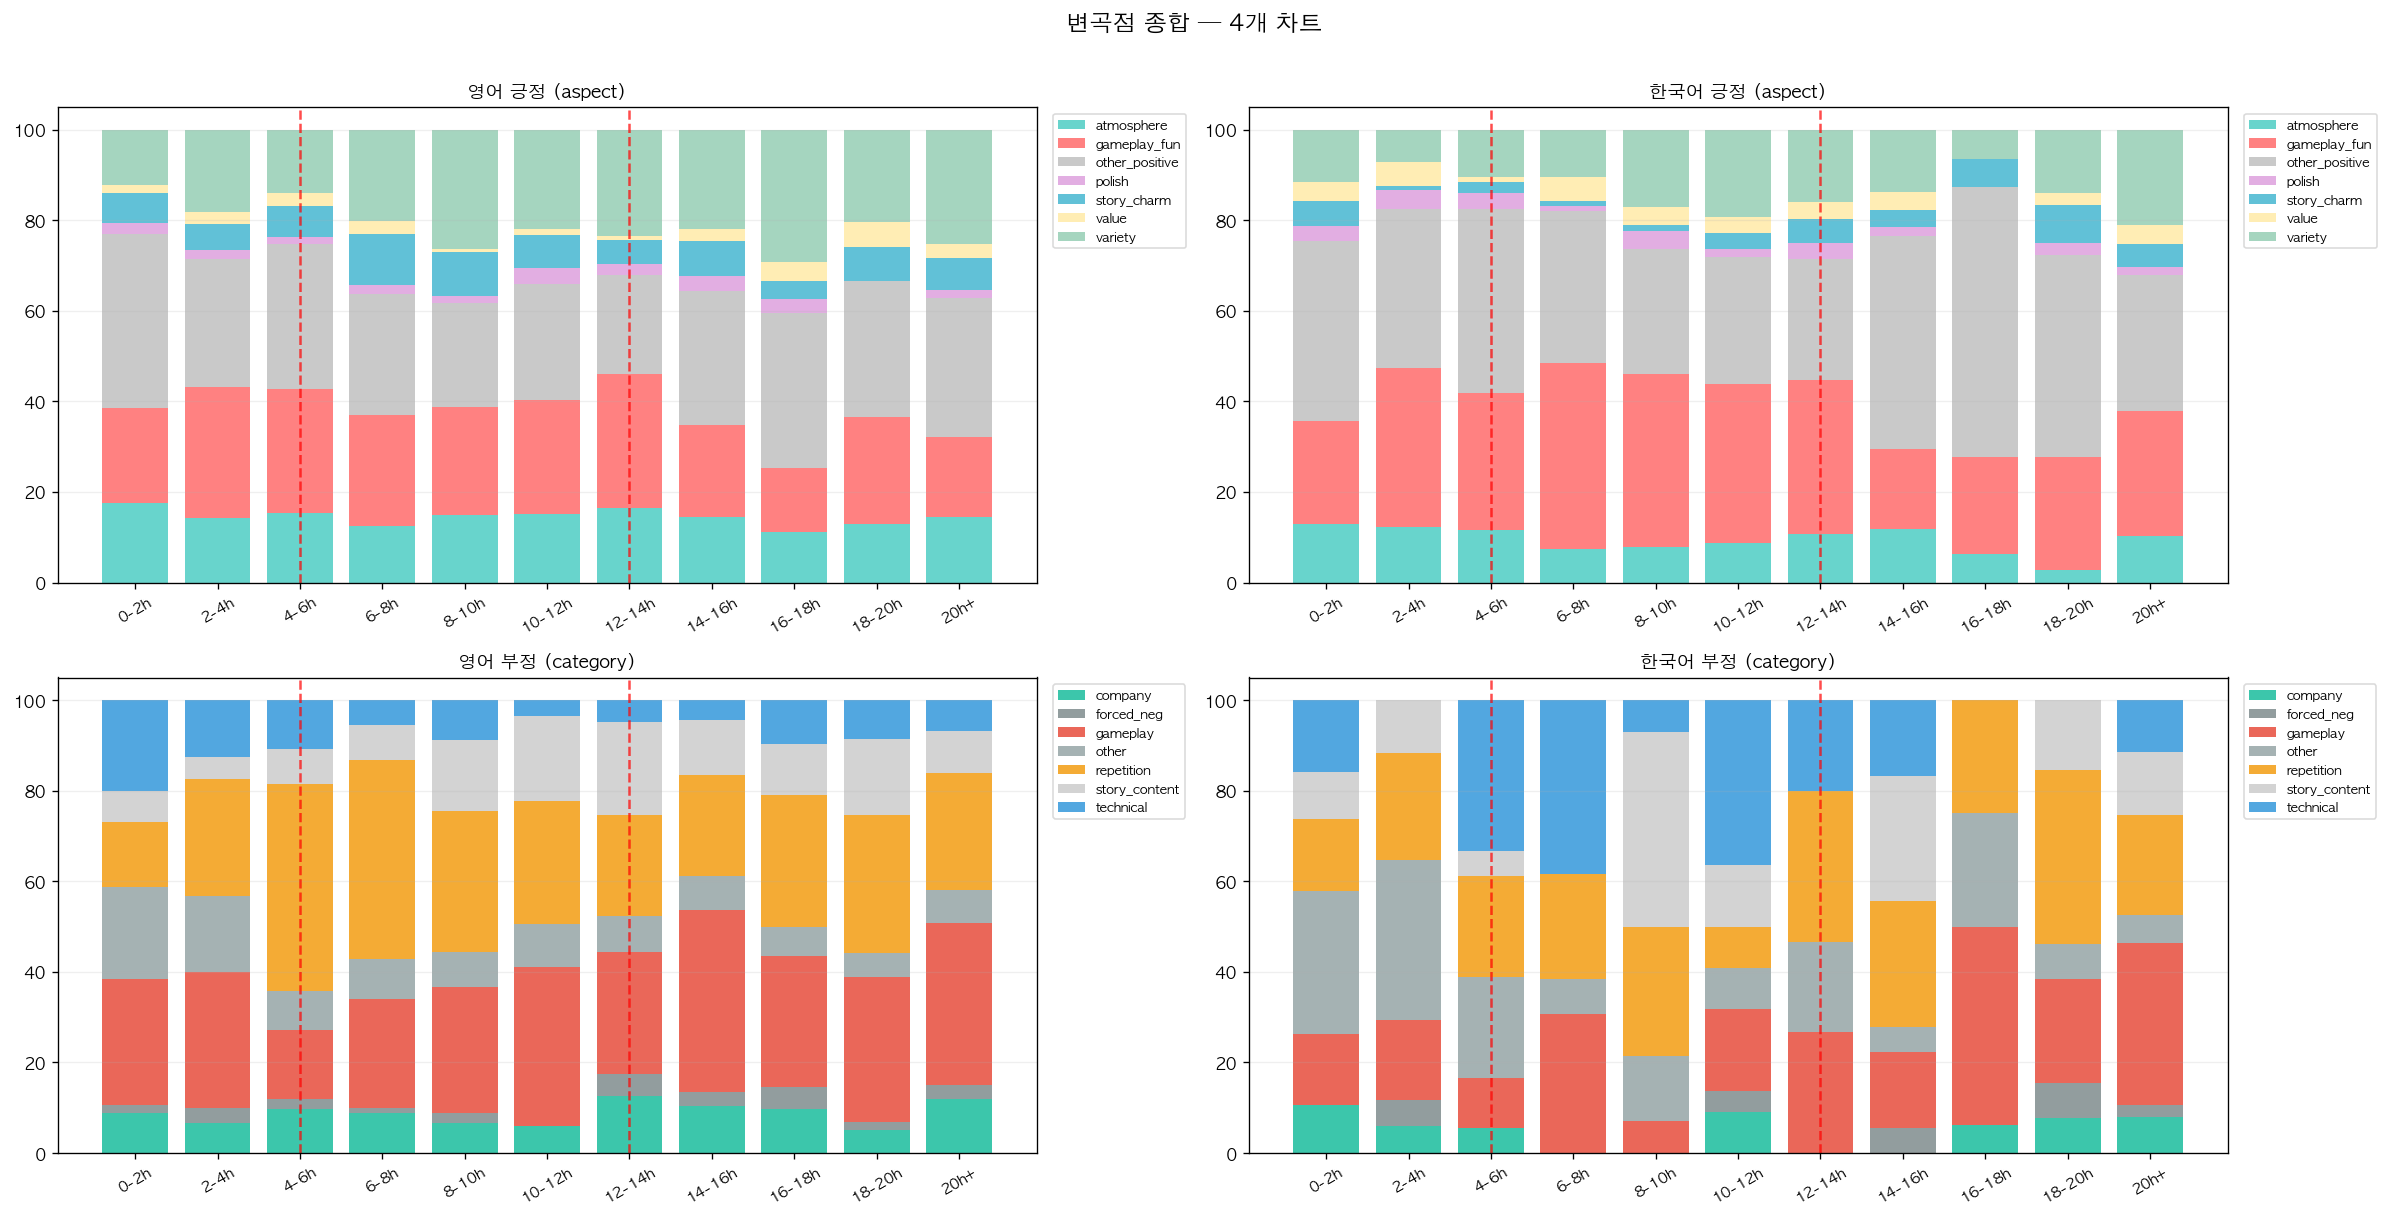

 저장: step6_inflection_overview.png


In [23]:
# 6-2. 4개 차트 나란히 배치 — 변곡점 세로선 포함
# (데이터 보고 변곡점 후보 확인 후 아래 inflection_bins 업데이트)

# ⚠️ 위 출력을 보고 변곡점 후보 빈을 여기에 기입
inflection_bins = ['4-6h', '12-14h']  # 예: ['6-8h', '12-14h']

fig6, axes = plt.subplots(2, 2, figsize=(20, 10))
datasets = [
    (aspect_comp_pct, ASPECT_COLORS, '영어 긍정 (aspect)', axes[0, 0]),
    (aspect_comp_ko_pct, ASPECT_COLORS, '한국어 긍정 (aspect)', axes[0, 1]),
    (cat_comp_pct, CATEGORY_COLORS, '영어 부정 (category)', axes[1, 0]),
    (cat_comp_ko_pct, CATEGORY_COLORS, '한국어 부정 (category)', axes[1, 1]),
]

for comp_pct, color_dict, title, ax in datasets:
    if comp_pct is None or len(comp_pct) == 0:
        ax.text(0.5, 0.5, '데이터 없음', transform=ax.transAxes, ha='center')
        continue
    
    x = range(len(comp_pct))
    bottom = np.zeros(len(comp_pct))
    
    for col in comp_pct.columns:
        color = color_dict.get(col, '#CCCCCC')
        ax.bar(x, comp_pct[col].values, bottom=bottom,
               color=color, label=col, alpha=0.85, width=0.8)
        bottom += comp_pct[col].values
    
    # 변곡점 세로선
    bin_list = list(comp_pct.index.astype(str))
    for ib in inflection_bins:
        if ib in bin_list:
            idx = bin_list.index(ib)
            ax.axvline(x=idx, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(comp_pct.index.astype(str), rotation=30, fontsize=9)
    ax.set_ylim(0, 105)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('변곡점 종합 — 4개 차트', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/step6_inflection_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step6_inflection_overview.png')

In [24]:
# 6-3. 최종 구간 확정 + 네이밍

LIGHT_SEGMENTS = {
    'tasting':     (2, 6),      # 찍먹 — 4-6h가 불만 변곡점이니까 여기까지
    'core_loop':   (6, 12),     # 코어 루프 — 변곡점 사이 구간
    'mid_immerse': (12, 16),    # 중반 몰입 — 한국어 긍정 변곡점 포함
    'near_clear':  (16, 20),    # 클리어 근접
    'post_clear':  (20, 9999),  # 포스트 클리어
}

SEGMENT_LABELS_KO = {
    'tasting':     '찍먹 (2-6h)',
    'core_loop':   '코어 루프 (6-12h)',
    'mid_immerse': '중반 몰입 (12-16h)',
    'near_clear':  '클리어 근접 (16-20h)',
    'post_clear':  '포스트 클리어 (20h+)',
}

# 각 구간 건수 확인
print('=== 최종 구간 건수 확인 ===')
for seg_name, (lo, hi) in LIGHT_SEGMENTS.items():
    n_en = len(pos_en[(pos_en['playtime_hours'] >= lo) & (pos_en['playtime_hours'] < hi)])
    n_ko = len(pos_ko[(pos_ko['playtime_hours'] >= lo) & (pos_ko['playtime_hours'] < hi)])
    print(f'[{seg_name}] {lo}~{hi}h | EN: {n_en}건 | KO: {n_ko}건')

=== 최종 구간 건수 확인 ===
[tasting] 2~6h | EN: 552건 | KO: 183건
[core_loop] 6~12h | EN: 614건 | KO: 228건
[mid_immerse] 12~16h | EN: 233건 | KO: 107건
[near_clear] 16~20h | EN: 192건 | KO: 83건
[post_clear] 20~9999h | EN: 914건 | KO: 253건


---
## STEP 7. 영어 vs 한국어 교차 비교 — 버터플라이 차트

> **목적**: 확정된 구간 기준으로, 영어/한국어 유저가 같은 구간에서 뭘 다르게 칭찬/비판하는지 비교.

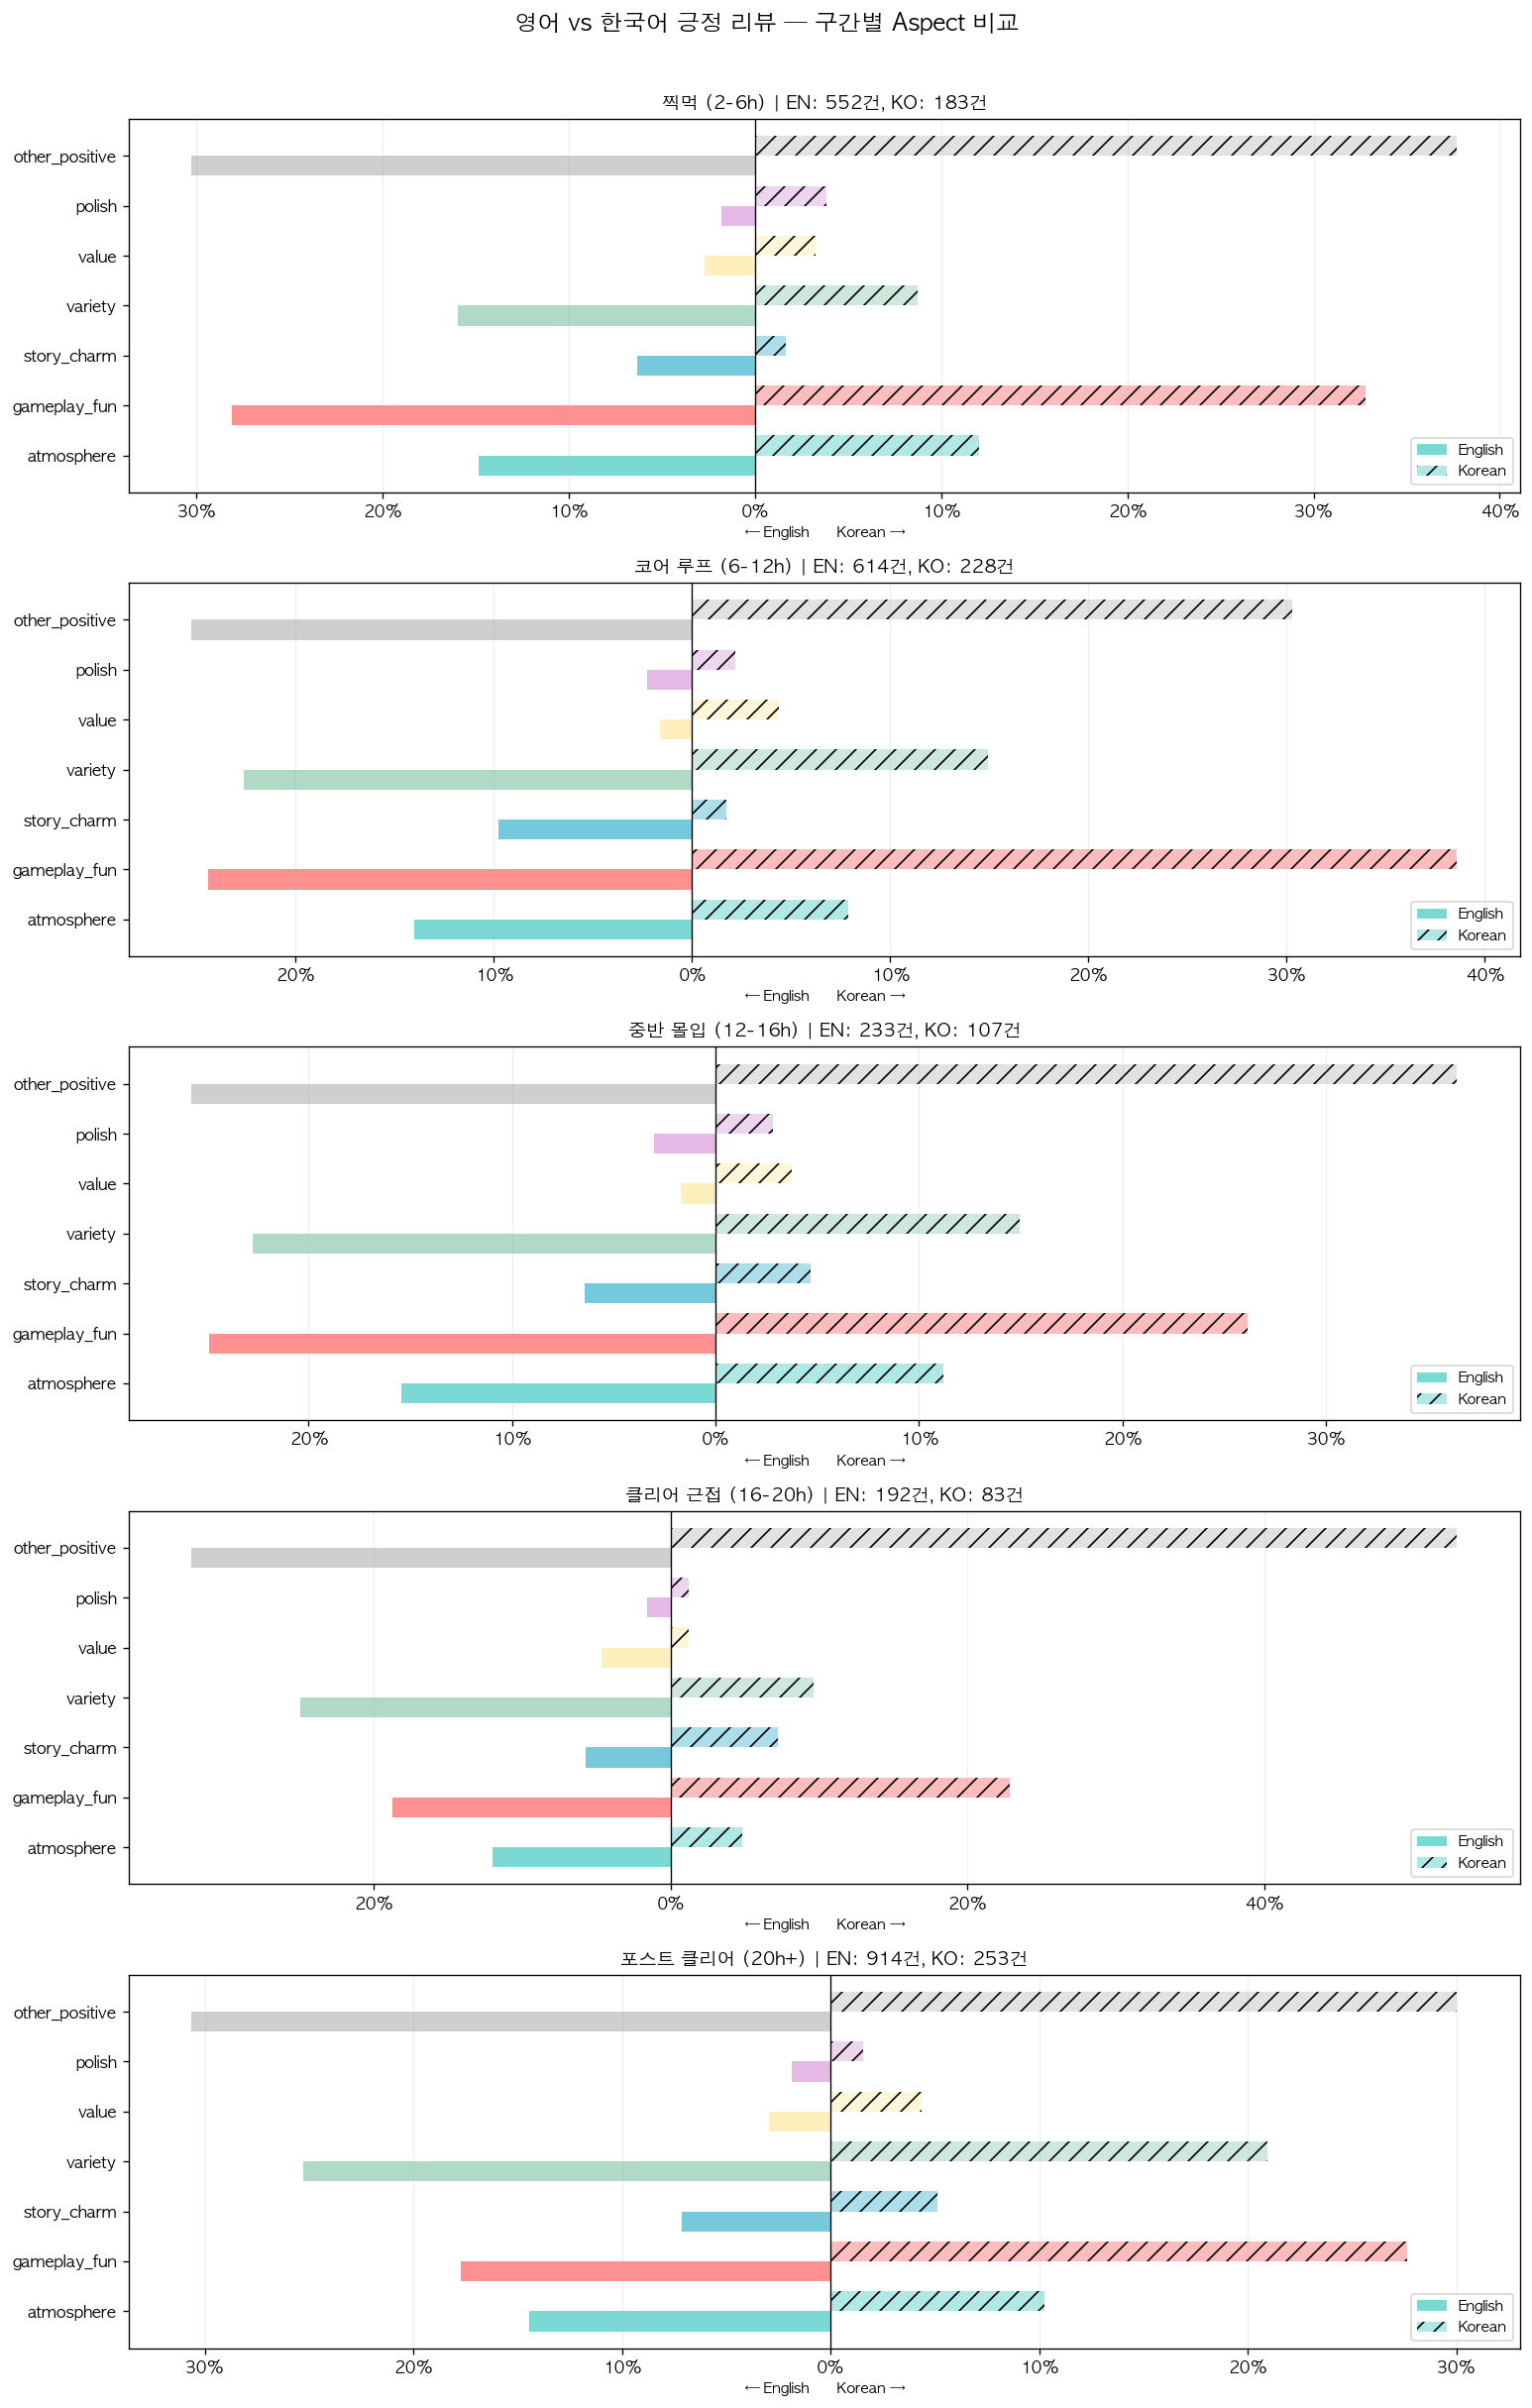

 저장: step7a_butterfly_pos_aspect.png


In [25]:
# 7-1. 버터플라이 차트 — 긍정 (aspect)

n_segs = len(LIGHT_SEGMENTS)
fig7a, axes = plt.subplots(n_segs, 1, figsize=(13, 4 * n_segs))
if n_segs == 1:
    axes = [axes]

aspects = list(ASPECT_COLORS.keys())
colors_list = [ASPECT_COLORS[a] for a in aspects]

for idx, (seg_name, (lo, hi)) in enumerate(LIGHT_SEGMENTS.items()):
    ax = axes[idx]
    
    en_seg = pos_en[(pos_en['playtime_hours'] >= lo) & (pos_en['playtime_hours'] < hi)]
    ko_seg = pos_ko[(pos_ko['playtime_hours'] >= lo) & (pos_ko['playtime_hours'] < hi)]
    
    en_dist = en_seg['aspect'].value_counts(normalize=True) * 100 if len(en_seg) > 0 else pd.Series(dtype=float)
    ko_dist = ko_seg['aspect'].value_counts(normalize=True) * 100 if len(ko_seg) > 0 else pd.Series(dtype=float)
    
    en_vals = [-en_dist.get(a, 0) for a in aspects]
    ko_vals = [ko_dist.get(a, 0) for a in aspects]
    
    y_pos = range(len(aspects))
    bars_en = ax.barh(y_pos, en_vals, color=colors_list, alpha=0.75, label='English', height=0.4, align='center')
    bars_ko = ax.barh([y + 0.4 for y in y_pos], ko_vals, color=colors_list, alpha=0.45,
                      label='Korean', height=0.4, align='center', hatch='//')
    
    ax.set_yticks([y + 0.2 for y in y_pos])
    ax.set_yticklabels(aspects, fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{SEGMENT_LABELS_KO[seg_name]} | EN: {len(en_seg)}건, KO: {len(ko_seg)}건',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('← English      Korean →', fontsize=9)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{abs(x):.0f}%'))
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.2)

plt.suptitle('영어 vs 한국어 긍정 리뷰 — 구간별 Aspect 비교', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/step7a_butterfly_pos_aspect.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step7a_butterfly_pos_aspect.png')

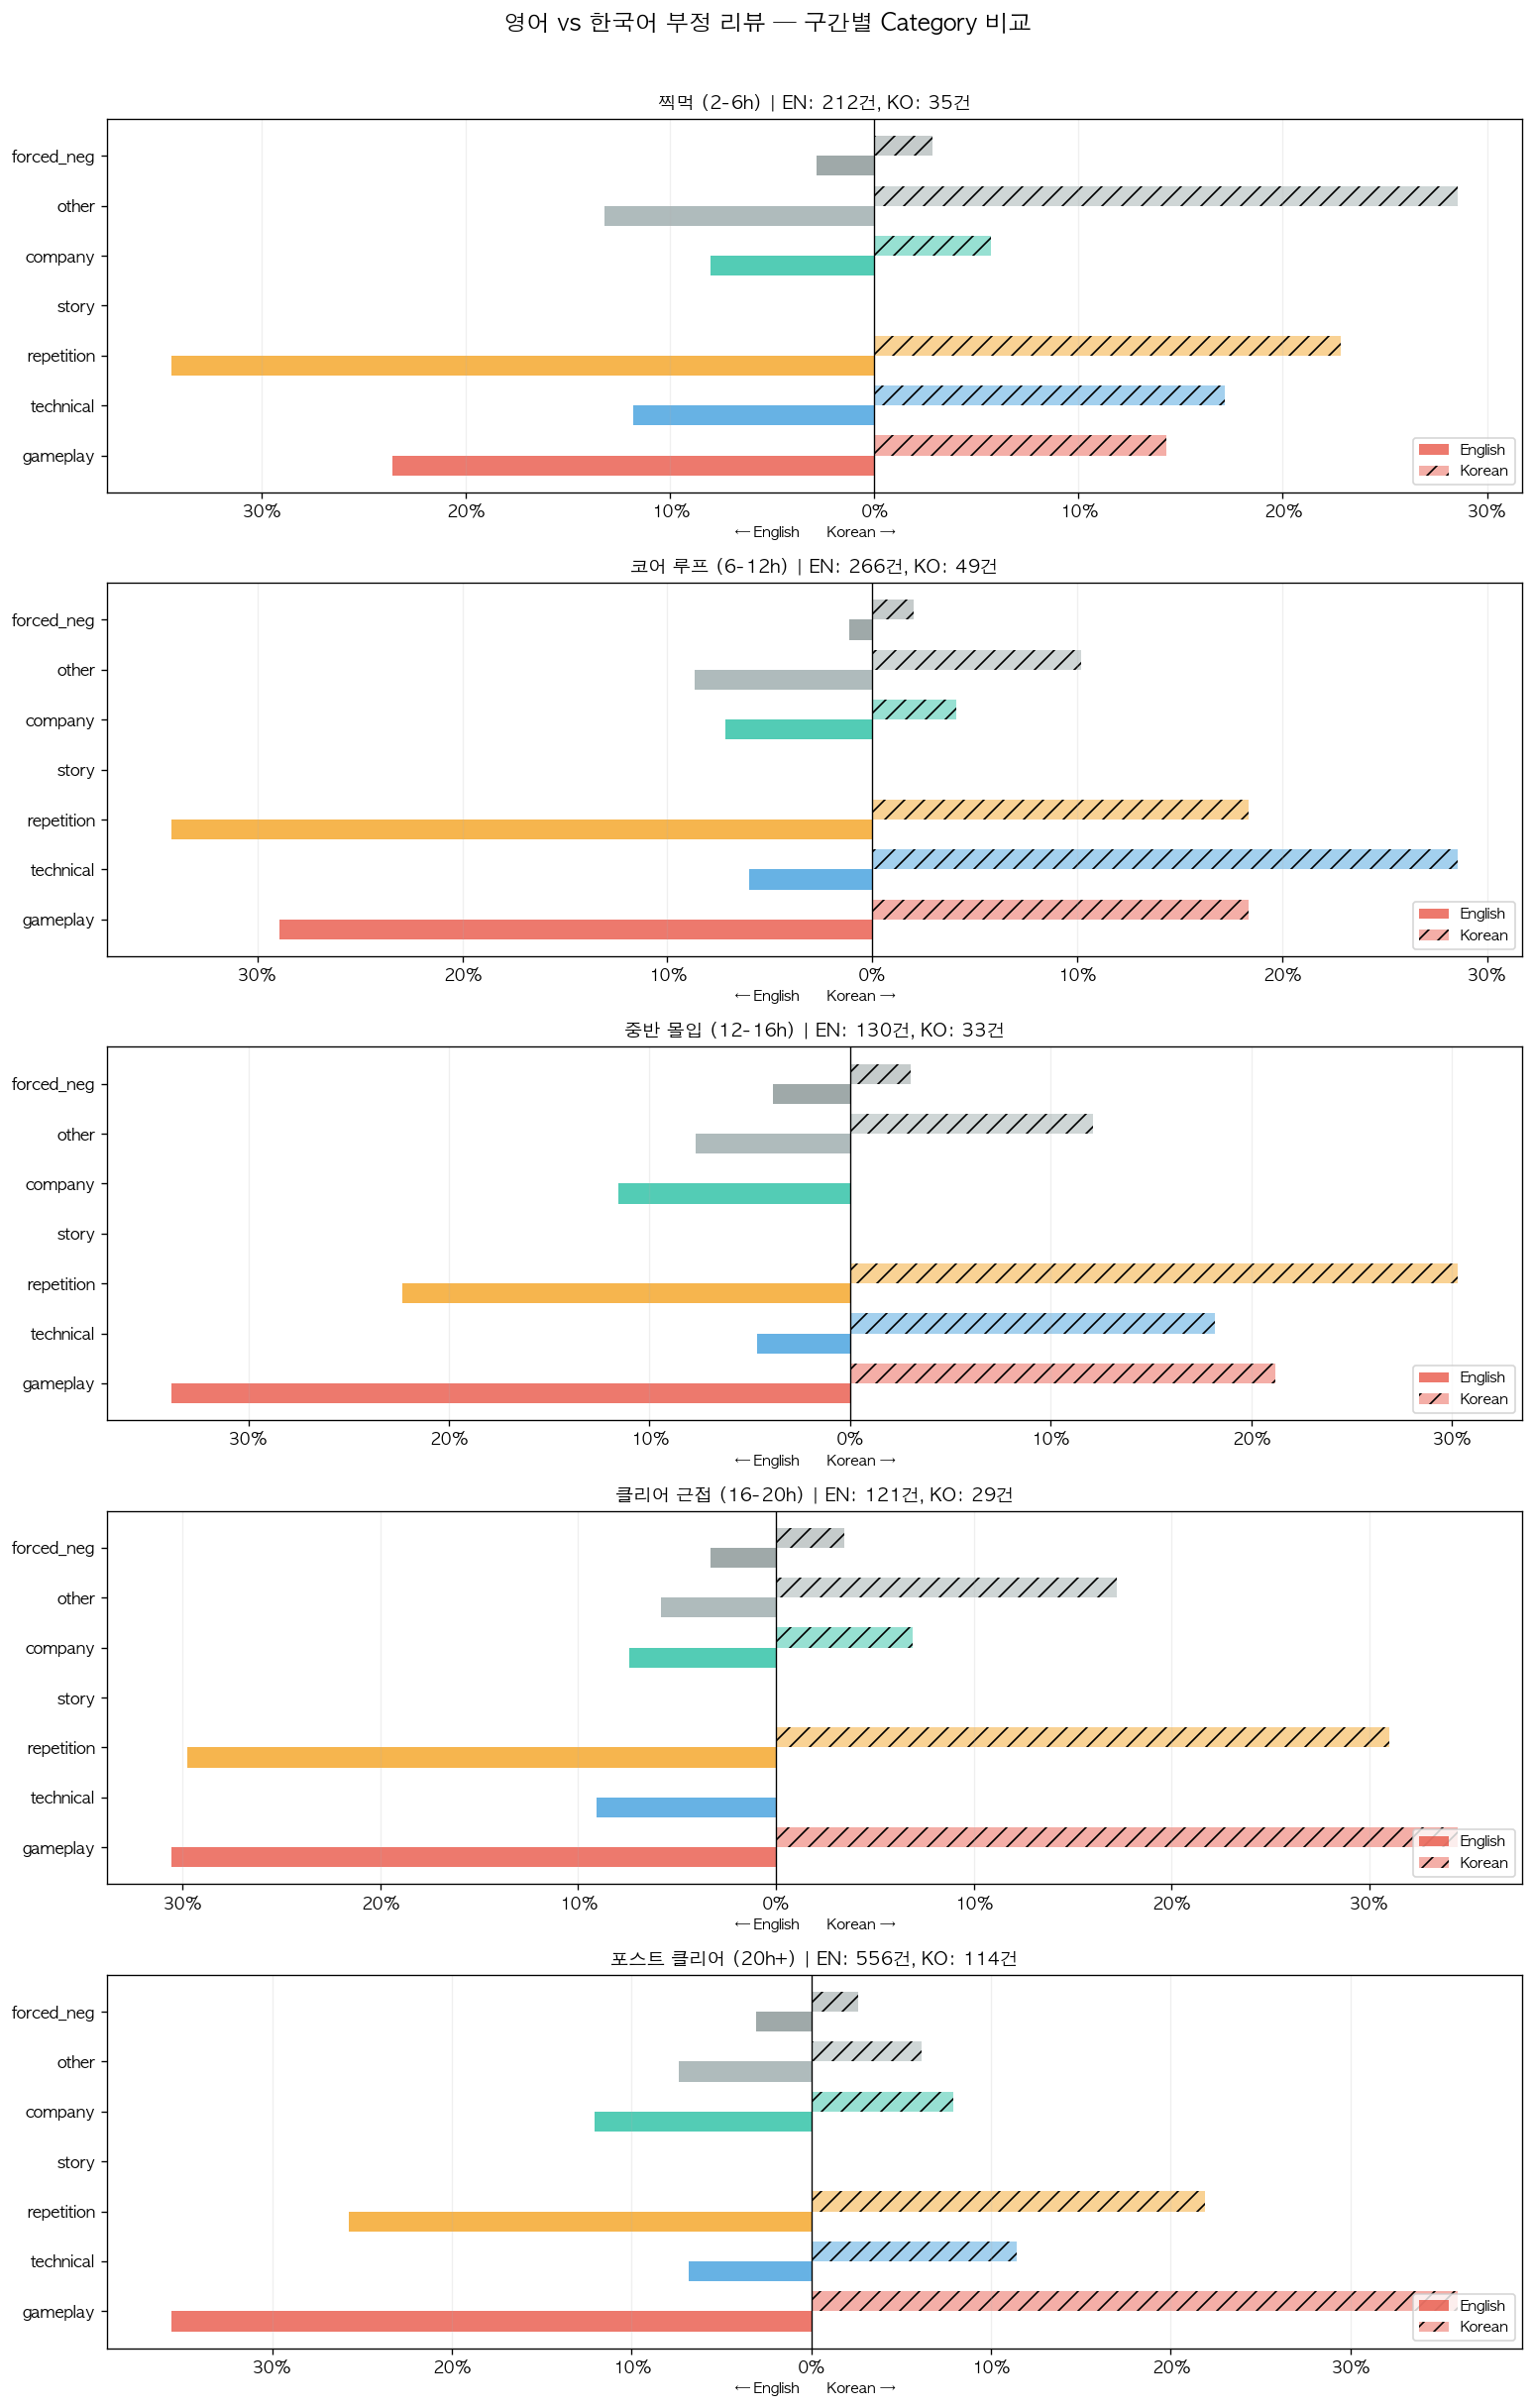

 저장: step7b_butterfly_neg_category.png


In [26]:
# 7-2. 버터플라이 차트 — 부정 (category)

fig7b, axes = plt.subplots(n_segs, 1, figsize=(13, 4 * n_segs))
if n_segs == 1:
    axes = [axes]

categories = list(CATEGORY_COLORS.keys())
cat_colors_list = [CATEGORY_COLORS[c] for c in categories]

for idx, (seg_name, (lo, hi)) in enumerate(LIGHT_SEGMENTS.items()):
    ax = axes[idx]
    
    en_seg = neg_en[(neg_en['playtime_hours'] >= lo) & (neg_en['playtime_hours'] < hi)]
    ko_seg = neg_ko[(neg_ko['playtime_hours'] >= lo) & (neg_ko['playtime_hours'] < hi)]
    
    en_dist = en_seg['category'].value_counts(normalize=True) * 100 if len(en_seg) > 0 else pd.Series(dtype=float)
    ko_dist = ko_seg['category'].value_counts(normalize=True) * 100 if len(ko_seg) > 0 else pd.Series(dtype=float)
    
    en_vals = [-en_dist.get(c, 0) for c in categories]
    ko_vals = [ko_dist.get(c, 0) for c in categories]
    
    y_pos = range(len(categories))
    ax.barh(y_pos, en_vals, color=cat_colors_list, alpha=0.75, label='English', height=0.4)
    ax.barh([y + 0.4 for y in y_pos], ko_vals, color=cat_colors_list, alpha=0.45,
            label='Korean', height=0.4, hatch='//')
    
    ax.set_yticks([y + 0.2 for y in y_pos])
    ax.set_yticklabels(categories, fontsize=10)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{SEGMENT_LABELS_KO[seg_name]} | EN: {len(en_seg)}건, KO: {len(ko_seg)}건',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('← English      Korean →', fontsize=9)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{abs(x):.0f}%'))
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(axis='x', alpha=0.2)

plt.suptitle('영어 vs 한국어 부정 리뷰 — 구간별 Category 비교', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/step7b_butterfly_neg_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step7b_butterfly_neg_category.png')

---
## STEP 8. "왜 엔딩까지 안 갔는가" — 이탈 인사이트

> **핵심 프레임**  
> 이 유저들의 문제는 DLC나 추가 콘텐츠가 아니다.  
> 메인 스토리 안에서 엔딩까지 이끌 모멘텀이 어딘가에서 끊겼다.

In [27]:
# 8-1. 리뷰 후 추가 플레이타임 분석

print('=== 구간별 이탈 지표 ===\n')
churn_summary = []

for seg_name, (lo, hi) in LIGHT_SEGMENTS.items():
    seg = full_en_pos[
        (full_en_pos['playtime_hours'] >= lo) &
        (full_en_pos['playtime_hours'] < hi) &
        full_en_pos['post_review_hours'].notna()
    ]
    
    if len(seg) == 0:
        continue
    
    median_post = seg['post_review_hours'].median()
    pct_no_play = (seg['post_review_hours'] <= 0.5).mean() * 100
    pct_reached_clear = ((seg['playtime_forever'] / 60) >= MAIN_STORY_CLEAR_HOURS).mean() * 100
    
    churn_summary.append({
        'segment': SEGMENT_LABELS_KO[seg_name],
        'n': len(seg),
        'median_post_h': round(median_post, 1),
        'pct_no_play': round(pct_no_play, 1),
        'pct_cleared': round(pct_reached_clear, 1),
    })
    print(f'[{SEGMENT_LABELS_KO[seg_name]}] n={len(seg):,} | '
          f'추가 플레이 중앙값: {median_post:.1f}h | '
          f'이탈(30분미만): {pct_no_play:.1f}% | '
          f'클리어 도달: {pct_reached_clear:.1f}%')

churn_df = pd.DataFrame(churn_summary)

=== 구간별 이탈 지표 ===

[찍먹 (2-6h)] n=6,435 | 추가 플레이 중앙값: 13.4h | 이탈(30분미만): 10.1% | 클리어 도달: 45.8%
[코어 루프 (6-12h)] n=7,504 | 추가 플레이 중앙값: 14.4h | 이탈(30분미만): 12.3% | 클리어 도달: 56.1%
[중반 몰입 (12-16h)] n=3,622 | 추가 플레이 중앙값: 15.1h | 이탈(30분미만): 12.4% | 클리어 도달: 68.5%
[클리어 근접 (16-20h)] n=2,807 | 추가 플레이 중앙값: 14.8h | 이탈(30분미만): 14.5% | 클리어 도달: 79.6%
[포스트 클리어 (20h+)] n=21,409 | 추가 플레이 중앙값: 5.1h | 이탈(30분미만): 33.9% | 클리어 도달: 100.0%


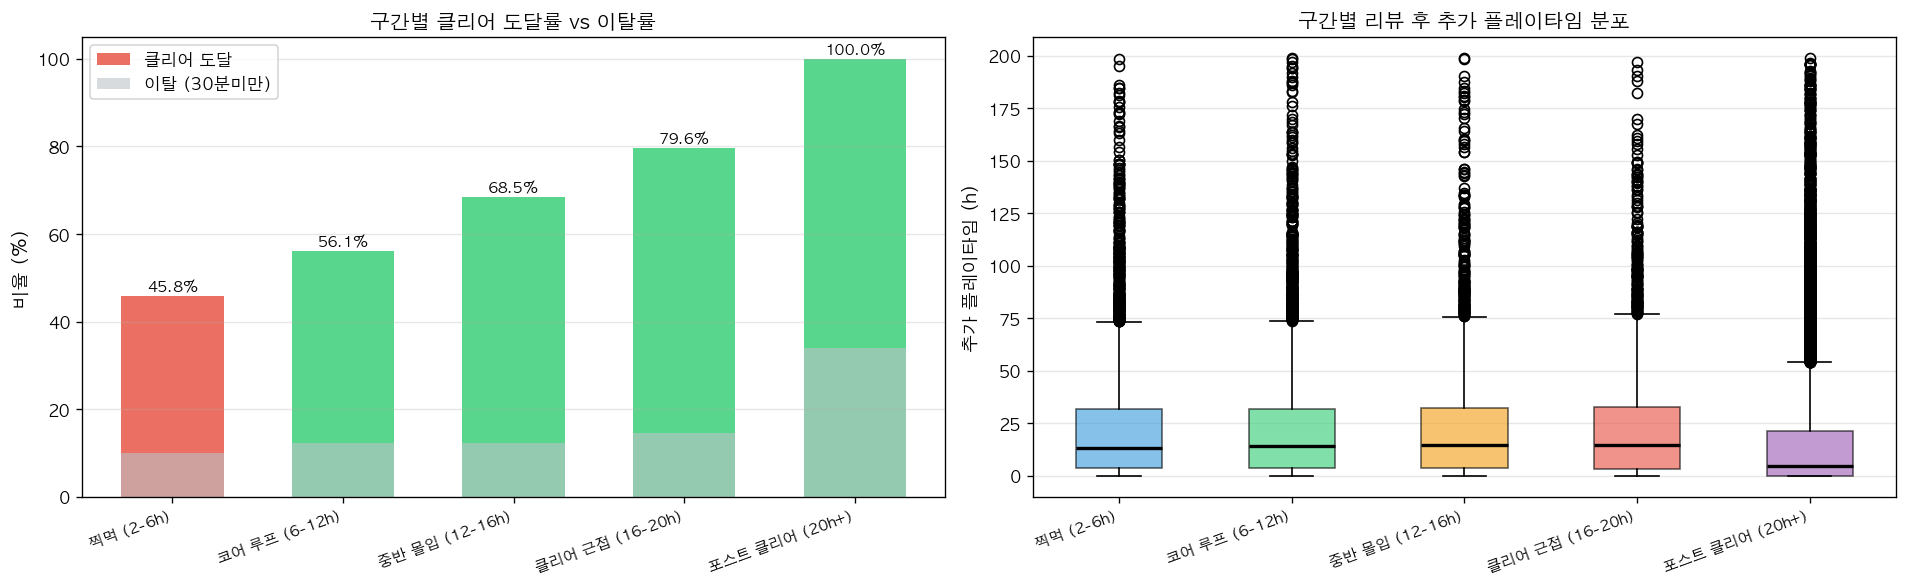

 저장: step8a_churn_analysis.png


In [28]:
# 8-1 시각화: 구간별 바이올린 플롯

fig8a, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 클리어 도달률 바 차트
ax = axes[0]
colors_bar = ['#E74C3C' if p < 50 else '#2ECC71' for p in churn_df['pct_cleared']]
bars = ax.bar(range(len(churn_df)), churn_df['pct_cleared'], color=colors_bar, alpha=0.8, width=0.6)
ax.bar(range(len(churn_df)), churn_df['pct_no_play'], color='#BDC3C7', alpha=0.6, width=0.6,
       bottom=0, label='이탈 (30분미만)')
ax.set_xticks(range(len(churn_df)))
ax.set_xticklabels(churn_df['segment'], rotation=20, fontsize=9, ha='right')
ax.set_ylabel('비율 (%)', fontsize=11)
ax.set_title('구간별 클리어 도달률 vs 이탈률', fontsize=12, fontweight='bold')
ax.legend(['클리어 도달', '이탈 (30분미만)'], fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, row in churn_df.iterrows():
    ax.text(i, row['pct_cleared'] + 1, f'{row["pct_cleared"]}%', ha='center', fontsize=9)

# 오른쪽: 구간별 추가 플레이타임 박스플롯
ax2 = axes[1]
seg_data = []
seg_labels = []
for seg_name, (lo, hi) in LIGHT_SEGMENTS.items():
    seg = full_en_pos[
        (full_en_pos['playtime_hours'] >= lo) &
        (full_en_pos['playtime_hours'] < hi) &
        full_en_pos['post_review_hours'].notna() &
        (full_en_pos['post_review_hours'] >= 0) &
        (full_en_pos['post_review_hours'] < 200)
    ]['post_review_hours']
    if len(seg) > 0:
        seg_data.append(seg.values)
        seg_labels.append(SEGMENT_LABELS_KO[seg_name])

bp = ax2.boxplot(seg_data, labels=seg_labels, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
colors_bp = ['#3498DB', '#2ECC71', '#F39C12', '#E74C3C', '#9B59B6']
for patch, color in zip(bp['boxes'], colors_bp[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_xticklabels(seg_labels, rotation=20, fontsize=9, ha='right')
ax2.set_ylabel('추가 플레이타임 (h)', fontsize=11)
ax2.set_title('구간별 리뷰 후 추가 플레이타임 분포', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/step8a_churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(' 저장: step8a_churn_analysis.png')

In [29]:
# 8-2. 긍정 리뷰 속 숨겨진 비판 (has_criticism = 'yes')

# has_criticism 컬럼 존재 여부 확인
if 'has_criticism' not in pos_en.columns:
    print('⚠️ has_criticism 컬럼 없음. pos_reviews_classified 스키마 확인 필요.')
    print('현재 컬럼:', pos_en.columns.tolist())
else:
    pos_with_criticism = pos_en[pos_en['has_criticism'] == 'yes'].copy()
    print(f'숨겨진 비판 있는 긍정 리뷰: {len(pos_with_criticism):,}건 ({len(pos_with_criticism)/len(pos_en)*100:.1f}%)')
    print()
    
    for seg_name, (lo, hi) in LIGHT_SEGMENTS.items():
        seg = pos_with_criticism[
            (pos_with_criticism['playtime_hours'] >= lo) &
            (pos_with_criticism['playtime_hours'] < hi)
        ]
        if len(seg) > 0 and 'criticism_topic' in seg.columns:
            print(f'\n[{SEGMENT_LABELS_KO[seg_name]}] 숨겨진 비판 ({len(seg)}건):')
            print(seg['criticism_topic'].value_counts().head(5).to_string())

숨겨진 비판 있는 긍정 리뷰: 299건 (10.0%)


[찍먹 (2-6h)] 숨겨진 비판 (37건):
criticism_topic
gameplay         13
other             8
repetition        5
technical         5
story_content     3

[코어 루프 (6-12h)] 숨겨진 비판 (52건):
criticism_topic
gameplay         19
other            15
technical        10
repetition        5
story_content     3

[중반 몰입 (12-16h)] 숨겨진 비판 (17건):
criticism_topic
gameplay         6
repetition       3
technical        3
story_content    3
other            2

[클리어 근접 (16-20h)] 숨겨진 비판 (18건):
criticism_topic
gameplay         6
repetition       5
technical        3
story_content    2
other            2

[포스트 클리어 (20h+)] 숨겨진 비판 (127건):
criticism_topic
repetition       40
gameplay         34
other            21
story_content    20
technical        10


In [30]:
# 8-3. 이탈 유저 vs 클리어 유저 키워드 비교

light_pos = full_en_pos[
    (full_en_pos['playtime_hours'] >= 2) &
    (full_en_pos['playtime_hours'] < 14) &
    full_en_pos['post_review_hours'].notna()
]

# 그룹 A: 이탈 유저 (리뷰 후 1h 미만)
churned = light_pos[light_pos['post_review_hours'] < 1]
# 그룹 B: 클리어 유저 (playtime_forever >= 20h)
cleared = light_pos[(light_pos['playtime_forever'] / 60) >= MAIN_STORY_CLEAR_HOURS]

print(f'이탈 유저 (2-14h, 추가 <1h): {len(churned):,}건')
print(f'클리어 유저 (2-14h, total ≥20h): {len(cleared):,}건')

# TF-IDF 비교
if len(churned) > 20 and len(cleared) > 20:
    tfidf_cmp = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
    all_texts = pd.concat([churned['cleaned_text'].dropna(), cleared['cleaned_text'].dropna()])
    tfidf_cmp.fit(all_texts)
    
    churned_vec = tfidf_cmp.transform(churned['cleaned_text'].dropna()).mean(axis=0).A1
    cleared_vec = tfidf_cmp.transform(cleared['cleaned_text'].dropna()).mean(axis=0).A1
    feature_names_cmp = tfidf_cmp.get_feature_names_out()
    
    diff_churned = churned_vec - cleared_vec
    diff_cleared = cleared_vec - churned_vec
    
    top_churned = [(feature_names_cmp[i], diff_churned[i]) for i in diff_churned.argsort()[-15:][::-1]]
    top_cleared = [(feature_names_cmp[i], diff_cleared[i]) for i in diff_cleared.argsort()[-15:][::-1]]
    
    print('\n이탈 유저 특징 키워드 (vs 클리어):')
    for kw, s in top_churned[:10]: print(f'  {kw}: {s:.4f}')
    
    print('\n클리어 유저 특징 키워드 (vs 이탈):')
    for kw, s in top_cleared[:10]: print(f'  {kw}: {s:.4f}')

이탈 유저 (2-14h, 추가 <1h): 2,248건
클리어 유저 (2-14h, total ≥20h): 8,439건

이탈 유저 특징 키워드 (vs 클리어):
  chill: 0.0162
  fish: 0.0139
  relax: 0.0128
  deck: 0.0111
  dive: 0.0109
  steam: 0.0097
  steam deck: 0.0085
  fun relax: 0.0036
  fun chill: 0.0030
  cool: 0.0026

클리어 유저 특징 키워드 (vs 이탈):
  love: 0.0091
  amazing: 0.0069
  addictive: 0.0069
  addict: 0.0068
  buy: 0.0049
  wait: 0.0038
  far: 0.0037
  worth: 0.0037
  character: 0.0034
  animation: 0.0033


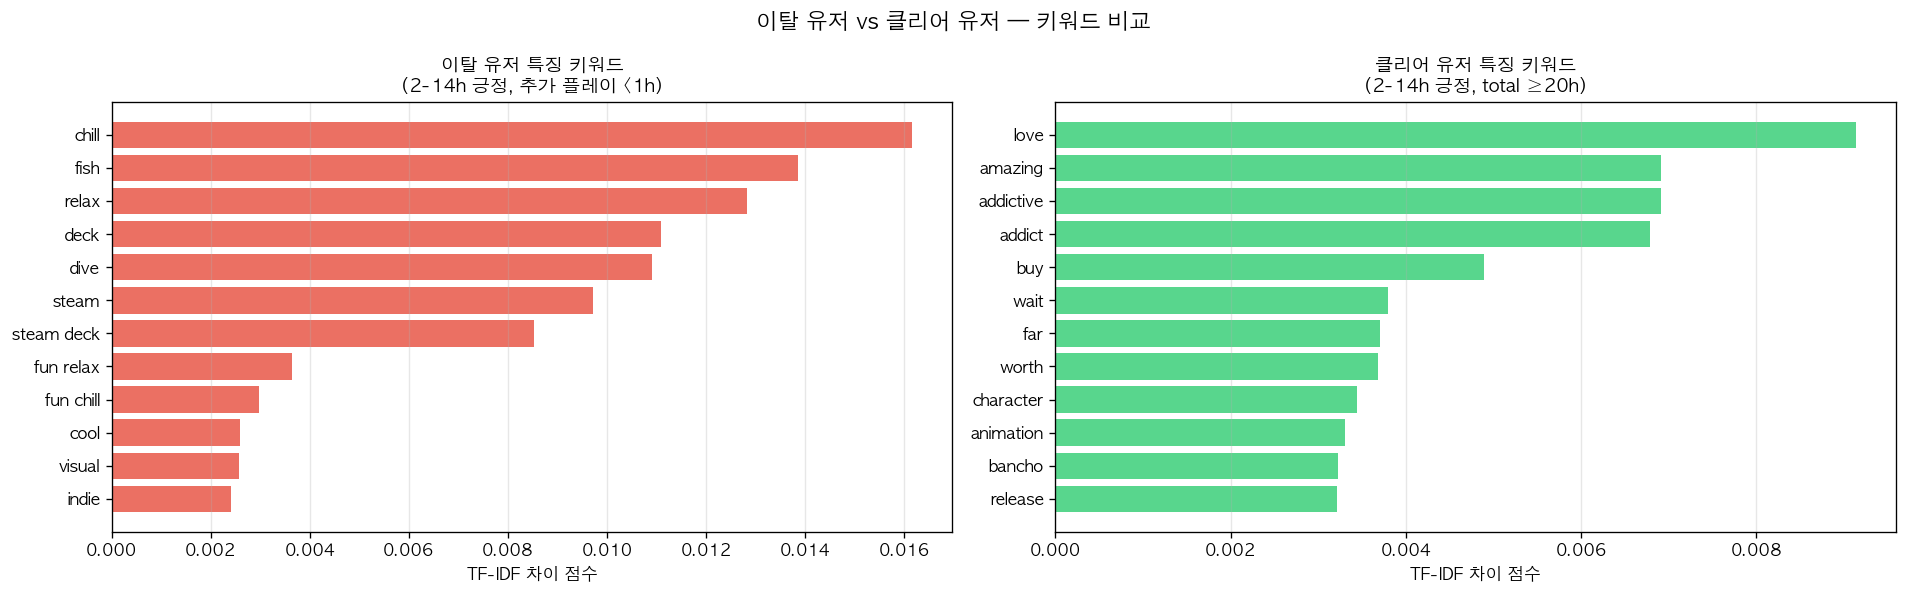

 저장: step8b_churned_vs_cleared_keywords.png


In [31]:
# 8-3 시각화: 이탈 vs 클리어 키워드 대비 바 차트

if len(churned) > 20 and len(cleared) > 20:
    n_show = 12
    fig8b, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5))
    
    # 이탈 유저 키워드
    kw_c = [kw for kw, _ in top_churned[:n_show]]
    sc_c = [s for _, s in top_churned[:n_show]]
    ax_left.barh(range(len(kw_c)), sc_c[::-1], color='#E74C3C', alpha=0.8)
    ax_left.set_yticks(range(len(kw_c)))
    ax_left.set_yticklabels(kw_c[::-1], fontsize=10)
    ax_left.set_title('이탈 유저 특징 키워드\n(2-14h 긍정, 추가 플레이 <1h)', fontsize=11, fontweight='bold')
    ax_left.set_xlabel('TF-IDF 차이 점수', fontsize=10)
    ax_left.grid(axis='x', alpha=0.3)
    
    # 클리어 유저 키워드
    kw_cl = [kw for kw, _ in top_cleared[:n_show]]
    sc_cl = [s for _, s in top_cleared[:n_show]]
    ax_right.barh(range(len(kw_cl)), sc_cl[::-1], color='#2ECC71', alpha=0.8)
    ax_right.set_yticks(range(len(kw_cl)))
    ax_right.set_yticklabels(kw_cl[::-1], fontsize=10)
    ax_right.set_title('클리어 유저 특징 키워드\n(2-14h 긍정, total ≥20h)', fontsize=11, fontweight='bold')
    ax_right.set_xlabel('TF-IDF 차이 점수', fontsize=10)
    ax_right.grid(axis='x', alpha=0.3)
    
    plt.suptitle('이탈 유저 vs 클리어 유저 — 키워드 비교', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/figures/step8b_churned_vs_cleared_keywords.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' 저장: step8b_churned_vs_cleared_keywords.png')


### 8-3b~d. 이탈 vs 클리어 유저 심화 분석

> **목적**: TF-IDF 키워드 차이(8-3)가 확연한데, 이를 3가지 방법으로 추가 검증  
> - **8-3b**: 실제 리뷰 원문 샘플 — 이탈/클리어 유저가 실제로 뭐라고 쓰는지 직접 읽기  
> - **8-3c**: 텍스트 특성 정량 비교 — 리뷰 길이, 모멘텀/피로감 단어 포함률 등  
> - **8-3d**: LLM 분류 데이터 교차 검증 — aspect 분포와 has_criticism 비율로 확인


In [32]:

# 8-3b. 이탈 vs 클리어 유저 — 실제 리뷰 전문 샘플 확인

N_SAMPLE = 5
np.random.seed(42)

def print_review_samples(df_group, label, n=N_SAMPLE):
    avail = df_group.dropna(subset=['review_text'])
    sample = avail.sample(min(n, len(avail)), random_state=42)

    print(f'\n{"=" * 68}')
    print(f' {label}  (총 {len(df_group)}건 중 {len(avail)}건 유효)')
    print('=' * 68)

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        pt     = row.get('playtime_hours', float('nan'))
        post   = row.get('post_review_hours', float('nan'))
        total  = row.get('playtime_forever', float('nan'))
        total_h = total / 60 if not pd.isna(total) else float('nan')
        print(f'\n[{i}] {pt:.1f}h 시점 리뷰  |  추가 플레이: {post:.1f}h  |  누적 total: {total_h:.1f}h')
        text = str(row['review_text'])
        print(text[:500] + ('...' if len(text) > 500 else ''))

if len(churned) > 0 and len(cleared) > 0:
    print_review_samples(churned, '◀ 이탈 유저 (2-14h 긍정, 추가 플레이 <1h)')
    print_review_samples(cleared, '▶ 클리어 유저 (2-14h 긍정, total ≥20h)')
else:
    print('⚠️ 이탈/클리어 유저 데이터 부족')



 ◀ 이탈 유저 (2-14h 긍정, 추가 플레이 <1h)  (총 2248건 중 2248건 유효)

[1] 8.2h 시점 리뷰  |  추가 플레이: 0.0h  |  누적 total: 8.2h
Super relaxing game with awesome visuals.

[2] 6.2h 시점 리뷰  |  추가 플레이: 0.0h  |  누적 total: 6.2h
One of the best indi games I have ever played. Thanks a lot to developers . Top!

[3] 10.1h 시점 리뷰  |  추가 플레이: 0.0h  |  누적 total: 10.1h
It doesn't need my glowing review piled onto the others to say that this is a brilliant little game, but here it is anyways.

[4] 12.5h 시점 리뷰  |  추가 플레이: 0.0h  |  누적 total: 12.5h
I have 0 LOVE for the sea people and stopped playing because of it.
I do love everything else :)

[5] 11.5h 시점 리뷰  |  추가 플레이: 0.0h  |  누적 total: 11.5h
dabe(David) da(the) divar(known go for a little silly dip under the water(clothed preferably))

 ▶ 클리어 유저 (2-14h 긍정, total ≥20h)  (총 8439건 중 8439건 유효)

[1] 3.6h 시점 리뷰  |  추가 플레이: 29.2h  |  누적 total: 32.8h
Really good fun, lots of cool elements to it! Looking forward to seeing more stuff from this game

[2] 5.1h 시점 리뷰  |  추가 플레이: 32.

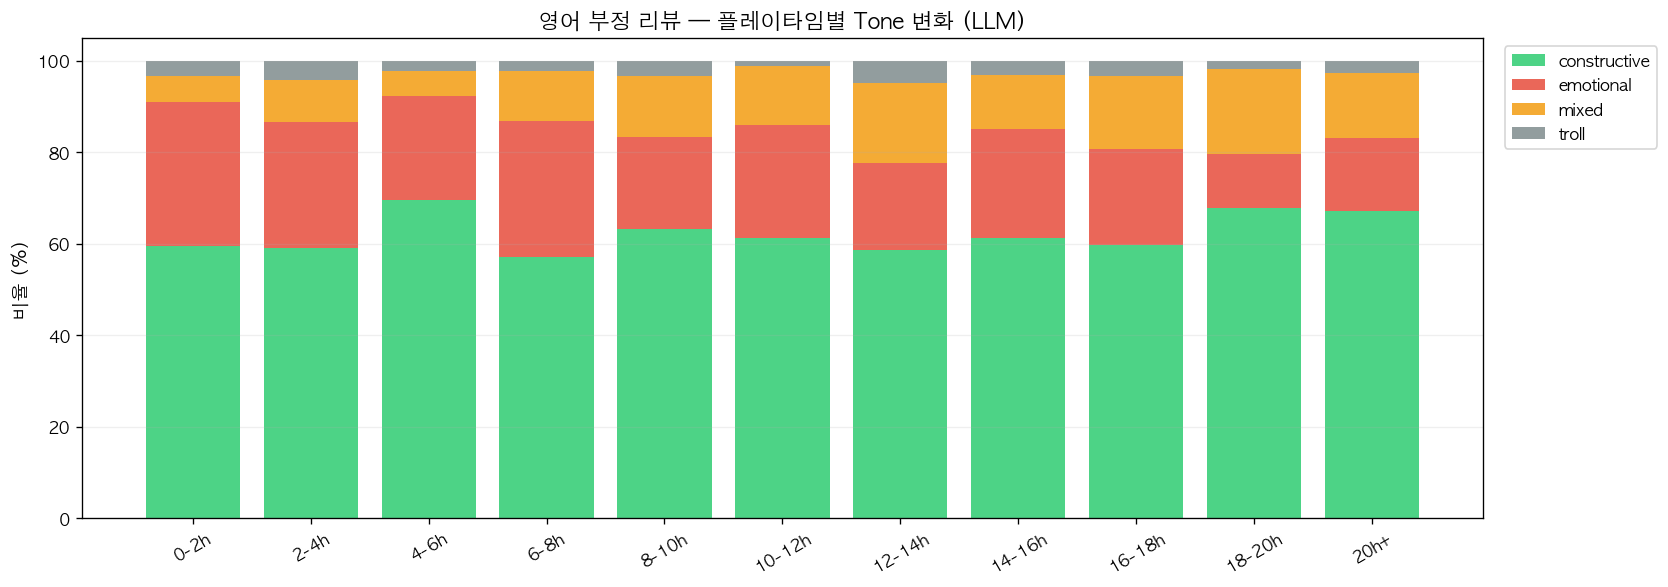

 저장: step8c_tone_change.png

해석 가이드:
- constructive 많은 구간 = "좋아하지만 아쉬운" 유저 (게임을 포기 안 함)
- emotional 많은 구간    = "진짜 불만족" (이탈 신호)


In [33]:
# 8-4. 부정 리뷰 tone 변화

if 'tone' in neg_en.columns:
    tone_comp = neg_en.groupby([EN_BIN_COL, 'tone'], observed=True).size().unstack(fill_value=0)
    tone_comp_pct = tone_comp.div(tone_comp.sum(axis=1), axis=0) * 100
    
    TONE_COLORS = {
        'constructive': '#2ECC71',
        'mixed':        '#F39C12',
        'emotional':    '#E74C3C',
        'troll':        '#7F8C8D',
    }
    
    fig8c, ax = plt.subplots(figsize=(14, 5))
    x = range(len(tone_comp_pct))
    bottom = np.zeros(len(tone_comp_pct))
    
    for col in tone_comp_pct.columns:
        color = TONE_COLORS.get(col, '#CCCCCC')
        ax.bar(x, tone_comp_pct[col].values, bottom=bottom,
               color=color, label=col, alpha=0.85, width=0.8)
        bottom += tone_comp_pct[col].values
    
    ax.set_xticks(x)
    ax.set_xticklabels(tone_comp_pct.index.astype(str), rotation=30, fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_ylabel('비율 (%)', fontsize=11)
    ax.set_title('영어 부정 리뷰 — 플레이타임별 Tone 변화 (LLM)', fontsize=13, fontweight='bold')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.2)
    
    plt.tight_layout()
    plt.savefig('../reports/figures/step8c_tone_change.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(' 저장: step8c_tone_change.png')
    print()
    print('해석 가이드:')
    print('- constructive 많은 구간 = "좋아하지만 아쉬운" 유저 (게임을 포기 안 함)')
    print('- emotional 많은 구간    = "진짜 불만족" (이탈 신호)')
else:
    print(' tone 컬럼 없음. neg_reviews_classified 스키마 확인 필요.')
    print('현재 컬럼:', neg_en.columns.tolist())

In [34]:
# 8-5. 이탈 vs 클리어 유저 — LLM aspect 교차 검증
if 'post_review_hours' in pos_en.columns and 'aspect' in pos_en.columns:
    light_pos_en = pos_en[
        (pos_en['playtime_hours'] >= 2) & (pos_en['playtime_hours'] < 14)
    ].copy()

    churned_llm = light_pos_en[light_pos_en['post_review_hours'] < 1]
    cleared_llm = light_pos_en[(light_pos_en['playtime_forever'] / 60) >= MAIN_STORY_CLEAR_HOURS]

    print(f'LLM 이탈: {len(churned_llm)}건 / 클리어: {len(cleared_llm)}건')

    if len(churned_llm) > 5 and len(cleared_llm) > 5:
        churned_aspect = churned_llm['aspect'].value_counts(normalize=True).mul(100).round(1)
        cleared_aspect = cleared_llm['aspect'].value_counts(normalize=True).mul(100).round(1)

        all_aspects = sorted(set(churned_aspect.index) | set(cleared_aspect.index))
        comparison_df = pd.DataFrame({
            '이탈(%)': [churned_aspect.get(a, 0) for a in all_aspects],
            '클리어(%)': [cleared_aspect.get(a, 0) for a in all_aspects],
        }, index=all_aspects)
        comparison_df['차이(클리어-이탈)'] = comparison_df['클리어(%)'] - comparison_df['이탈(%)']
        comparison_df = comparison_df.sort_values('차이(클리어-이탈)', ascending=False)
        print(comparison_df.to_string())

        # 시각화
        fig, ax = plt.subplots(figsize=(10, 5))
        x = range(len(comparison_df))
        w = 0.35
        ax.bar([i - w/2 for i in x], comparison_df['이탈(%)'],
               width=w, label='이탈 유저', color='#E74C3C', alpha=0.8)
        ax.bar([i + w/2 for i in x], comparison_df['클리어(%)'],
               width=w, label='클리어 유저', color='#2ECC71', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(comparison_df.index, rotation=30, ha='right', fontsize=10)
        ax.set_ylabel('비율 (%)')
        ax.set_title('이탈 vs 클리어 유저 — aspect 구성 비교 (영어 2-14h LLM)', fontweight='bold')
        ax.legend(); ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('../reports/figures/step8d_llm_aspect_churn_vs_clear.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('저장: step8d_llm_aspect_churn_vs_clear.png')

        if 'has_criticism' in pos_en.columns:
            print('\n=== has_criticism 비율 ===')
            for label, grp in [('이탈', churned_llm), ('클리어', cleared_llm)]:
                rate = (grp['has_criticism'] == 'yes').mean() * 100
                print(f'  {label}: {rate:.1f}%')

=== top sub_category ===
sub_category
none             1129
gameplay          227
story_content     137
repetition         85
technical          28
company            27
other              16
Name: count, dtype: int64

=== 구간별 sub_category Top3 ===

[0-2h] (364건)
  none: 288건 (79.1%)
  gameplay: 25건 (6.9%)
  story_content: 16건 (4.4%)

[2-4h] (120건)
  none: 88건 (73.3%)
  gameplay: 11건 (9.2%)
  story_content: 9건 (7.5%)

[4-6h] (92건)
  none: 66건 (71.7%)
  gameplay: 12건 (13.0%)
  repetition: 7건 (7.6%)

[6-8h] (91건)
  none: 65건 (71.4%)
  story_content: 8건 (8.8%)
  gameplay: 8건 (8.8%)

[8-10h] (90건)
  none: 57건 (63.3%)
  gameplay: 16건 (17.8%)
  repetition: 9건 (10.0%)

[10-12h] (85건)
  none: 52건 (61.2%)
  story_content: 15건 (17.6%)
  gameplay: 13건 (15.3%)

[12-14h] (63건)
  none: 41건 (65.1%)
  gameplay: 12건 (19.0%)
  story_content: 8건 (12.7%)

[14-16h] (67건)
  none: 53건 (79.1%)
  gameplay: 6건 (9.0%)
  story_content: 4건 (6.0%)

[16-18h] (62건)
  none: 43건 (69.4%)
  gameplay: 11건 (17.7%)
  story_

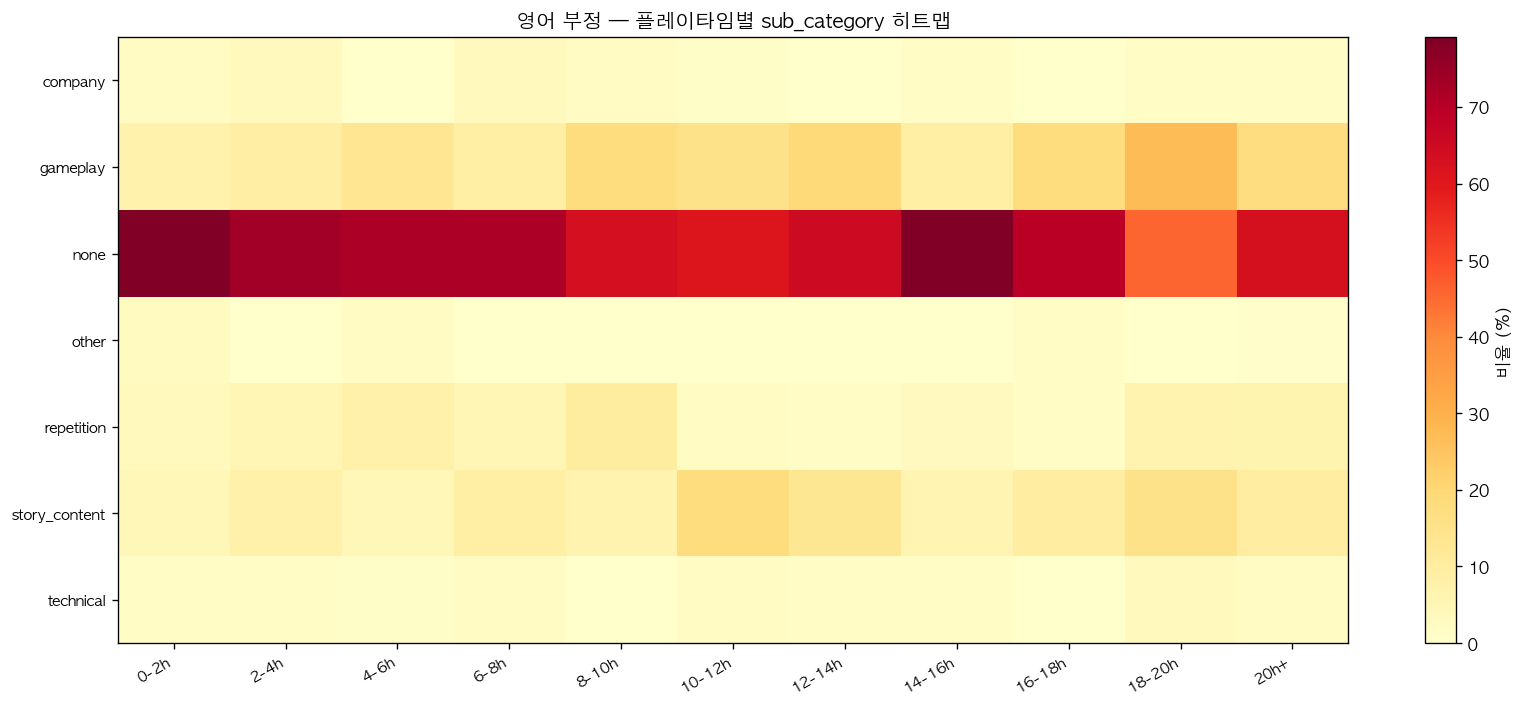

저장: step8e_subcategory_heatmap.png


In [35]:
# 8-6. 부정 리뷰 sub_category별 구간 변화 (tone이 flat → 더 세분화)
if 'sub_category' in neg_en.columns:
    print('=== top sub_category ===')
    print(neg_en['sub_category'].value_counts().head(12))

    # 구간별 top3
    seg_col = EN_BIN_COL
    print('\n=== 구간별 sub_category Top3 ===')
    for bin_label in neg_en[seg_col].cat.categories:
        seg = neg_en[neg_en[seg_col] == bin_label]
        if len(seg) >= 5:
            top3 = seg['sub_category'].value_counts().head(3)
            print(f'\n[{bin_label}] ({len(seg)}건)')
            for sub, cnt in top3.items():
                print(f'  {sub}: {cnt}건 ({cnt/len(seg)*100:.1f}%)')

    # 히트맵
    top_subs = neg_en['sub_category'].value_counts().head(10).index.tolist()
    sub_comp = neg_en[neg_en['sub_category'].isin(top_subs)].groupby(
        [seg_col, 'sub_category'], observed=True
    ).size().unstack(fill_value=0)
    sub_pct = sub_comp.div(sub_comp.sum(axis=1), axis=0).mul(100)

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(sub_pct.T.values, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=sub_pct.values.max())
    ax.set_xticks(range(len(sub_pct)))
    ax.set_xticklabels(sub_pct.index.astype(str), rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(sub_pct.columns)))
    ax.set_yticklabels(sub_pct.columns, fontsize=9)
    plt.colorbar(im, ax=ax, label='비율 (%)')
    ax.set_title('영어 부정 — 플레이타임별 sub_category 히트맵', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig('../reports/figures/step8e_subcategory_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('저장: step8e_subcategory_heatmap.png')
else:
    print('⚠️ sub_category 컬럼 없음. neg_en 컬럼:', neg_en.columns.tolist())

---
## STEP 9-1. 이탈 vs 클리어 유저 aspect 분포 차이 — Chi-square 검정

**가설**: 이탈 유저와 클리어 유저는 칭찬하는 aspect 구성이 통계적으로 다르다  
(이탈 유저 → `atmosphere` 비율 높음 / 클리어 유저 → `variety` 비율 높음 예측)

In [43]:
from scipy import stats as scipy_stats

print('=' * 68)
print(' STEP 9-2. 이탈 vs 클리어 — aspect 분포 차이 (Chi-square 검정)')
print('=' * 68)

# aspect 컬럼 존재 확인
if 'aspect' not in pos_en.columns:
    print(' aspect 컬럼 없음. pos_en 컬럼:', pos_en.columns.tolist())
else:
    # ── 그룹 정의 (STEP 9-1과 동일, group_a / group_b 재사용) ─────────
    # 가드 조건
    if len(group_a) < 30 or len(group_b) < 30:
        print(f" 샘플 수 부족: A={len(group_a)}, B={len(group_b)} — 결과 해석 주의")

    ga_asp = group_a[['aspect']].copy()
    ga_asp['user_group'] = '클리어'
    gb_asp = group_b[['aspect']].copy()
    gb_asp['user_group'] = '이탈'
    combined_asp = pd.concat([ga_asp, gb_asp])

    # ── 교차표 생성 ─────────────────────────────────────────────────
    ct_s92     = pd.crosstab(combined_asp['aspect'], combined_asp['user_group'])
    ct_pct_s92 = ct_s92.div(ct_s92.sum(axis=0), axis=1).mul(100).round(1)

    ct_display = ct_s92.copy()
    for col in ct_s92.columns:
        ct_display[col + ' (%)'] = ct_pct_s92[col]

    print('\n교차표 (건수 + 비율):')
    print(ct_display.to_string())

    # ── Chi-square 검정 ─────────────────────────────────────────────
    chi2_s92, p_s92, df_s92, expected_s92 = scipy_stats.chi2_contingency(ct_s92)
    sig_s92 = '유의 (α=0.05)' if p_s92 < 0.05 else '비유의 (α=0.05)'

    print(f'\nχ²({df_s92}) = {chi2_s92:.2f},  p = {p_s92:.4f}  →  {sig_s92}')

    # ── 표준화 잔차 (유의한 경우) ─────────────────────────────────────
    if p_s92 < 0.05:
        std_resid = (ct_s92.values - expected_s92) / np.sqrt(expected_s92)
        resid_df  = pd.DataFrame(
            std_resid,
            index=ct_s92.index,
            columns=['잔차_' + c for c in ct_s92.columns]
        )
        print('\n표준화 잔차:')
        print(resid_df.round(2).to_string())

        # |잔차| > 2 셀 강조
        sig_cells = [
            (idx, col, resid_df.loc[idx, col])
            for idx in resid_df.index
            for col in resid_df.columns
            if abs(resid_df.loc[idx, col]) > 2
        ]
        sig_cells.sort(key=lambda x: abs(x[2]), reverse=True)

        if sig_cells:
            print('\n⭐ 유의미한 셀 (|잔차| > 2):')
            for asp, grp, val in sig_cells:
                direction = '과다(↑)' if val > 0 else '과소(↓)'
                print(f'  {asp:20s} × {grp}: 잔차 = {val:+.2f}  {direction}')

        top_str = ', '.join([f'{a}({g[3:]}:{v:+.1f})' for a, g, v in sig_cells[:3]]) if sig_cells else '없음'
        print(f"""
> **결과**: χ²({df_s92}) = {chi2_s92:.2f}, p = {p_s92:.4f} → {sig_s92}
> **핵심 셀**: {top_str}

""")
    else:
        print(f'\n → aspect 분포는 이탈/클리어 그룹 간 통계적 차이 없음 (p = {p_s92:.4f})')
        print(f"""
> **결과**: χ²({df_s92}) = {chi2_s92:.2f}, p = {p_s92:.4f} → {sig_s92}

""")

 STEP 9-2. 이탈 vs 클리어 — aspect 분포 차이 (Chi-square 검정)

교차표 (건수 + 비율):
user_group       이탈  클리어  이탈 (%)  클리어 (%)
aspect                                   
atmosphere       90  289    15.3     14.5
gameplay_fun    154  421    26.1     21.2
other_positive  173  580    29.3     29.2
polish           14   37     2.4      1.9
story_charm      44  149     7.5      7.5
value            13   56     2.2      2.8
variety         102  455    17.3     22.9

χ²(6) = 12.95,  p = 0.0438  →  유의 (α=0.05)

표준화 잔차:
                잔차_이탈  잔차_클리어
aspect                       
atmosphere       0.35   -0.19
gameplay_fun     1.95   -1.06
other_positive   0.05   -0.02
polish           0.68   -0.37
story_charm     -0.03    0.02
value           -0.70    0.38
variety         -2.26    1.23

⭐ 유의미한 셀 (|잔차| > 2):
  variety              × 잔차_이탈: 잔차 = -2.26  과소(↓)

> **결과**: χ²(6) = 12.95, p = 0.0438 → 유의 (α=0.05)
> **핵심 셀**: variety(이탈:-2.3)




- variety를 칭찬한 유저가 이탈 그룹에 기대보다 유의미하게 적다.
    - 다양하다고 느낀 유저는 이탈하지 않고 엔딩가지 갔다.

"aspect 분포의 카이제곱 검정 결과(χ²=12.95, p=0.044), 이탈 유저 그룹에서 variety를 칭찬한 비율이 통계적으로 유의미하게 낮았다. '재밌다'는 감탄만으로는 엔딩까지 이끌 수 없고, '다양하다'는 인식이 결정적이다."

---
## STEP 9. 인사이트 종합

In [39]:
# 9-1. 발견 정리 테이블 (데이터 기반으로 채우기)

print('=== 구간별 인사이트 정리 테이블 ===')
print()

summary_rows = []
for seg_name, (lo, hi) in LIGHT_SEGMENTS.items():
    # 지배 aspect
    en_seg_pos = pos_en[(pos_en['playtime_hours'] >= lo) & (pos_en['playtime_hours'] < hi)]
    dominant_aspect = en_seg_pos['aspect'].value_counts().index[0] if len(en_seg_pos) > 0 and 'aspect' in en_seg_pos.columns else 'N/A'
    
    # 지배 category
    en_seg_neg = neg_en[(neg_en['playtime_hours'] >= lo) & (neg_en['playtime_hours'] < hi)]
    dominant_cat = en_seg_neg['category'].value_counts().index[0] if len(en_seg_neg) > 0 and 'category' in en_seg_neg.columns else 'N/A'
    
    # 이탈 지표
    churn_row = churn_df[churn_df['segment'] == SEGMENT_LABELS_KO[seg_name]]
    pct_cleared = churn_row['pct_cleared'].values[0] if len(churn_row) > 0 else 'N/A'
    pct_no_play = churn_row['pct_no_play'].values[0] if len(churn_row) > 0 else 'N/A'
    
    row = {
        '구간': SEGMENT_LABELS_KO[seg_name],
        '지배 aspect (EN)': dominant_aspect,
        '지배 category (EN)': dominant_cat,
        '클리어 도달률': f'{pct_cleared}%' if isinstance(pct_cleared, float) else pct_cleared,
        '이탈률(30분미만)': f'{pct_no_play}%' if isinstance(pct_no_play, float) else pct_no_play,
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

=== 구간별 인사이트 정리 테이블 ===

             구간 지배 aspect (EN) 지배 category (EN) 클리어 도달률 이탈률(30분미만)
      찍먹 (2-6h) other_positive       repetition   45.8%      10.1%
  코어 루프 (6-12h) other_positive       repetition   56.1%      12.3%
 중반 몰입 (12-16h) other_positive         gameplay   68.5%      12.4%
클리어 근접 (16-20h) other_positive         gameplay   79.6%      14.5%
 포스트 클리어 (20h+) other_positive         gameplay  100.0%      33.9%


In [40]:

# ================================================================
# 추가 분석: 구간별 불만 원인 심층 + 클리어 예측 요인
# 가설검정_라이트유저긍정률.ipynb의 마지막에 추가
# ================================================================

# ================================================================
# 추가 1. 구간별 부정 리뷰 원문에서 "구체적으로 뭐가 문제인가"
# ================================================================

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print('=' * 70)
print(' 추가 분석 1: 구간별 부정 리뷰 — 불만의 구체적 원인')
print('=' * 70)

# 영어 부정 리뷰만 (LLM 분류, anthropic)
neg_en_all = neg_classified[
    (neg_classified['language_group'] == 'english') & 
    (neg_classified['classify_method'] == 'anthropic') if 'classify_method' in neg_classified.columns else True
].copy()

# 구간 매핑
LIGHT_SEGMENTS = {
    'tasting':     (2, 6),
    'core_loop':   (6, 12),
    'mid_immerse': (12, 16),
    'near_clear':  (16, 20),
    'post_clear':  (20, 9999),
}

SEGMENT_LABELS = {
    'tasting':     '찍먹 (2-6h)',
    'core_loop':   '코어 루프 (6-12h)',
    'mid_immerse': '중반 몰입 (12-16h)',
    'near_clear':  '클리어 근접 (16-20h)',
    'post_clear':  '포스트 클리어 (20h+)',
}

def assign_segment(hours):
    for seg_name, (lo, hi) in LIGHT_SEGMENTS.items():
        if lo <= hours < hi:
            return seg_name
    return None

neg_en_all['light_segment'] = neg_en_all['playtime_hours'].apply(assign_segment)
neg_en_all = neg_en_all[neg_en_all['light_segment'].notna()]

# --- 1-1. 구간별 × category별 TF-IDF 특징 키워드 ---
print('\n[1-1] 구간별 × category별 특징 키워드 (부정 리뷰)')
print('-' * 60)

for seg_name, label in SEGMENT_LABELS.items():
    seg = neg_en_all[neg_en_all['light_segment'] == seg_name]
    if len(seg) < 10:
        print(f'\n[{label}] 건수 부족 ({len(seg)}건), 스킵')
        continue
    
    print(f'\n{"=" * 60}')
    print(f'[{label}] 총 {len(seg)}건')
    print(f'  category 분포: {seg["category"].value_counts().to_dict()}')
    
    # 이 구간의 주요 카테고리 Top 3에 대해 원문 키워드 추출
    top_cats = seg['category'].value_counts().head(3).index.tolist()
    
    for cat in top_cats:
        cat_reviews = seg[seg['category'] == cat]['review_text'].dropna()
        if len(cat_reviews) < 5:
            continue
        
        # TF-IDF로 이 카테고리 리뷰의 핵심 키워드
        try:
            tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), stop_words='english')
            mat = tfidf.fit_transform(cat_reviews)
            mean_scores = mat.mean(axis=0).A1
            feature_names = tfidf.get_feature_names_out()
            top_idx = mean_scores.argsort()[-8:][::-1]
            top_kws = [(feature_names[i], mean_scores[i]) for i in top_idx]
            
            print(f'\n  [{cat}] {len(cat_reviews)}건 — 핵심 키워드:')
            for kw, score in top_kws:
                print(f'    {kw}: {score:.4f}')
        except:
            print(f'  [{cat}] TF-IDF 실패 (건수: {len(cat_reviews)})')

# --- 1-2. 구간별 부정 리뷰 원문 샘플 (category별 대표 리뷰) ---
print('\n\n' + '=' * 70)
print(' [1-2] 구간별 부정 리뷰 원문 샘플')
print('=' * 70)

for seg_name, label in SEGMENT_LABELS.items():
    seg = neg_en_all[neg_en_all['light_segment'] == seg_name]
    if len(seg) < 5:
        continue
    
    print(f'\n{"=" * 60}')
    print(f'[{label}]')
    
    # 가장 많은 카테고리 Top 2의 대표 리뷰 2개씩
    top_cats = seg['category'].value_counts().head(2).index.tolist()
    for cat in top_cats:
        cat_reviews = seg[seg['category'] == cat].sort_values('weighted_vote_score', ascending=False)
        print(f'\n  --- {cat} (도움됨 점수 높은 순) ---')
        for _, row in cat_reviews.head(2).iterrows():
            text = str(row['review_text'])[:200].replace('\n', ' ')
            hours = row['playtime_hours']
            reason = str(row.get('reason', ''))[:100]
            print(f'  [{hours:.1f}h] {text}')
            if reason and reason != 'nan':
                print(f'    → LLM 분류 근거: {reason}')
            print()


# ================================================================
# 추가 2. 클리어 유저 vs 이탈 유저의 aspect 분포 차이
# ================================================================

print('\n\n' + '=' * 70)
print(' 추가 분석 2: 클리어 유저 vs 이탈 유저 — aspect가 다른가?')
print('=' * 70)

# 영어 긍정 LLM 분류 데이터에 post_review 정보 추가
pos_en = pos_classified[pos_classified['language_group'] == 'english'].copy()

# playtime_at_review가 pos_classified에 없는 경우 full_en에서 보완
if 'playtime_at_review' not in pos_en.columns:
    pos_en = pos_en.merge(
        full_en[['review_id', 'playtime_at_review']].drop_duplicates('review_id'),
        on='review_id', how='left'
    )

pos_en['light_segment'] = pos_en['playtime_hours'].apply(assign_segment)

# 2~14h 구간만 (찍먹 + 코어 루프 + 중반 몰입)
target_segs = ['tasting', 'core_loop', 'mid_immerse']
pos_light = pos_en[pos_en['light_segment'].isin(target_segs)].copy()

# 이탈 vs 클리어 분류
pos_light['post_review_hours'] = (pos_light['playtime_forever'] - pos_light['playtime_at_review']) / 60.0
pos_light['user_type'] = 'other'
pos_light.loc[pos_light['post_review_hours'] < 1, 'user_type'] = 'churned'
pos_light.loc[(pos_light['playtime_forever'] / 60.0) >= 20, 'user_type'] = 'cleared'

print(f'\n2~16h 긍정 리뷰 유저 분류:')
print(pos_light['user_type'].value_counts())

# --- 2-1. 이탈 vs 클리어 aspect 분포 비교 ---
print('\n[2-1] Aspect 분포 비교')
print('-' * 60)

for utype in ['churned', 'cleared']:
    subset = pos_light[pos_light['user_type'] == utype]
    if len(subset) == 0:
        continue
    dist = subset['aspect'].value_counts(normalize=True) * 100
    print(f'\n  [{utype}] {len(subset)}건:')
    for asp, pct in dist.items():
        print(f'    {asp}: {pct:.1f}%')

# --- 2-2. 이탈 vs 클리어의 has_criticism 비율 차이 ---
print('\n[2-2] 숨겨진 비판 보유율 비교')
print('-' * 60)

for utype in ['churned', 'cleared']:
    subset = pos_light[pos_light['user_type'] == utype]
    if len(subset) == 0:
        continue
    crit_rate = (subset['has_criticism'] == 'yes').mean() * 100
    print(f'  [{utype}] {len(subset)}건 중 비판 보유: {crit_rate:.1f}%')

    # 비판이 있는 경우 criticism_topic 분포
    with_crit = subset[subset['has_criticism'] == 'yes']
    if len(with_crit) > 0:
        print(f'    criticism_topic: {with_crit["criticism_topic"].value_counts().to_dict()}')

# --- 2-3. 구간별 × 유저 타입별 aspect 비교 ---
print('\n[2-3] 구간별 × 유저 타입별 1위 aspect')
print('-' * 60)

for seg_name in target_segs:
    label = SEGMENT_LABELS[seg_name]
    seg = pos_light[pos_light['light_segment'] == seg_name]
    
    print(f'\n  [{label}]')
    for utype in ['churned', 'cleared']:
        subset = seg[seg['user_type'] == utype]
        if len(subset) < 10:
            print(f'    {utype}: 건수 부족 ({len(subset)}건)')
            continue
        top_asp = subset['aspect'].value_counts().head(3)
        top_str = ' / '.join([f'{a}({n})' for a, n in top_asp.items()])
        print(f'    {utype} ({len(subset)}건): {top_str}')


# ================================================================
# 추가 3. "어떤 칭찬을 한 유저가 클리어까지 가는가" — aspect별 클리어율
# ================================================================

print('\n\n' + '=' * 70)
print(' 추가 분석 3: aspect별 클리어 도달률 — 어떤 칭찬이 클리어를 예측하는가?')
print('=' * 70)

# 2~16h 긍정 리뷰 유저 전체 (이탈/클리어/기타 포함)
pos_light_all = pos_en[pos_en['light_segment'].isin(target_segs)].copy()
pos_light_all['reached_clear'] = ((pos_light_all['playtime_forever'] / 60.0) >= 20).astype(int)

print('\n[3-1] Aspect별 클리어 도달률')
print('-' * 60)

aspect_clear = pos_light_all.groupby('aspect').agg(
    total=('reached_clear', 'count'),
    cleared=('reached_clear', 'sum'),
).assign(
    clear_rate=lambda x: x['cleared'] / x['total'] * 100
).sort_values('clear_rate', ascending=False)

for asp, row in aspect_clear.iterrows():
    bar = '█' * int(row['clear_rate'] / 2)
    print(f'  {asp:20s} {row["clear_rate"]:5.1f}% ({int(row["cleared"])}/{int(row["total"])}) {bar}')

# 전체 평균
avg_clear = pos_light_all['reached_clear'].mean() * 100
print(f'\n  {"전체 평균":20s} {avg_clear:5.1f}%')

# --- 3-2. has_criticism 여부별 클리어율 ---
print('\n[3-2] 숨겨진 비판 여부별 클리어 도달률')
print('-' * 60)

for crit_val in ['yes', 'no']:
    subset = pos_light_all[pos_light_all['has_criticism'] == crit_val]
    if len(subset) > 0:
        cr = subset['reached_clear'].mean() * 100
        print(f'  has_criticism={crit_val}: {cr:.1f}% ({subset["reached_clear"].sum()}/{len(subset)})')


# ================================================================
# 추가 4. 한국어 동일 분석 (간략 버전)
# ================================================================

print('\n\n' + '=' * 70)
print(' 추가 분석 4: 한국어 — 구간별 부정 불만 원인 + 클리어 예측')
print('=' * 70)

# 한국어 부정
neg_ko_all = neg_classified[
    neg_classified['language_group'] == 'korean'
].copy()
neg_ko_all['light_segment'] = neg_ko_all['playtime_hours'].apply(assign_segment)
neg_ko_all = neg_ko_all[neg_ko_all['light_segment'].notna()]

print('\n[4-1] 한국어 부정 — 구간별 category + sub_category')
for seg_name, label in SEGMENT_LABELS.items():
    seg = neg_ko_all[neg_ko_all['light_segment'] == seg_name]
    if len(seg) < 3:
        print(f'\n[{label}] 건수 부족 ({len(seg)}건)')
        continue
    print(f'\n[{label}] {len(seg)}건')
    print(f'  category: {seg["category"].value_counts().head(3).to_dict()}')
    sub = seg[seg['sub_category'] != 'none']['sub_category'].value_counts().head(3)
    if len(sub) > 0:
        print(f'  sub_category (none 제외): {sub.to_dict()}')
    
    # 원문 샘플 1개
    sample = seg.sort_values('weighted_vote_score', ascending=False).head(1)
    for _, row in sample.iterrows():
        text = str(row['review_text'])[:150].replace('\n', ' ')
        print(f'  대표 리뷰: [{row["playtime_hours"]:.1f}h] {text}')

# 한국어 긍정 — aspect별 클리어율
pos_ko = pos_classified[pos_classified['language_group'] == 'korean'].copy()
pos_ko['light_segment'] = pos_ko['playtime_hours'].apply(assign_segment)
pos_ko_light = pos_ko[pos_ko['light_segment'].isin(target_segs)].copy()

if 'playtime_forever' in pos_ko_light.columns and len(pos_ko_light) > 0:
    pos_ko_light['reached_clear'] = ((pos_ko_light['playtime_forever'] / 60.0) >= 20).astype(int)
    
    print('\n[4-2] 한국어 — Aspect별 클리어 도달률')
    ko_aspect_clear = pos_ko_light.groupby('aspect').agg(
        total=('reached_clear', 'count'),
        cleared=('reached_clear', 'sum'),
    ).assign(
        clear_rate=lambda x: x['cleared'] / x['total'] * 100
    ).sort_values('clear_rate', ascending=False)
    
    for asp, row in ko_aspect_clear.iterrows():
        print(f'  {asp:20s} {row["clear_rate"]:5.1f}% ({int(row["cleared"])}/{int(row["total"])})')


# ================================================================
# 추가 5. "6시간의 벽" 전후 비교 — 전문 데이터로 대규모 검증
# ================================================================

print('\n\n' + '=' * 70)
print(' 추가 분석 5: 전문 데이터 — 6h 전후 키워드 변화 + 이탈 유저 특성')
print('=' * 70)

# full_en (전문 데이터) 사용
full_en_pos = full_en[full_en['voted_up'] == 1].copy()
full_en_pos['post_review_hours'] = (full_en_pos['playtime_forever'] - full_en_pos['playtime_at_review']) / 60.0
full_en_pos['reached_clear'] = ((full_en_pos['playtime_forever'] / 60.0) >= 20).astype(int)

# 5-1. 4~8h 구간 (6h 전후) — 이탈 vs 클리어 키워드 비교
print('\n[5-1] 4~8h 구간 — "6시간의 벽" 전후 이탈 vs 클리어')

wall_zone = full_en_pos[
    (full_en_pos['playtime_hours'] >= 4) & 
    (full_en_pos['playtime_hours'] < 8)
]

wall_churned = wall_zone[wall_zone['post_review_hours'] < 1]
wall_cleared = wall_zone[wall_zone['reached_clear'] == 1]

print(f'  4~8h 긍정 유저: {len(wall_zone):,}건')
print(f'  이탈 (추가 <1h): {len(wall_churned):,}건')
print(f'  클리어 (total ≥20h): {len(wall_cleared):,}건')

if len(wall_churned) >= 50 and len(wall_cleared) >= 50:
    # TF-IDF 차이 키워드
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), stop_words='english')
    
    all_texts = pd.concat([wall_churned['cleaned_text'], wall_cleared['cleaned_text']])
    tfidf.fit(all_texts)
    
    churned_vec = tfidf.transform(wall_churned['cleaned_text']).mean(axis=0).A1
    cleared_vec = tfidf.transform(wall_cleared['cleaned_text']).mean(axis=0).A1
    
    diff = churned_vec - cleared_vec
    feature_names = tfidf.get_feature_names_out()
    
    # 이탈 유저 특징
    top_churned_idx = diff.argsort()[-10:][::-1]
    print('\n  이탈 유저(4~8h) 특징 키워드:')
    for i in top_churned_idx:
        print(f'    {feature_names[i]}: {diff[i]:.4f}')
    
    # 클리어 유저 특징
    top_cleared_idx = diff.argsort()[:10]
    print('\n  클리어 유저(4~8h) 특징 키워드:')
    for i in top_cleared_idx:
        print(f'    {feature_names[i]}: {-diff[i]:.4f}')

# 5-2. LDA 토픽 — 이탈 vs 클리어에서 토픽 분포가 다른가?
print('\n[5-2] 4~8h — 이탈 vs 클리어 LDA 토픽 분포')

for utype, subset in [('이탈', wall_churned), ('클리어', wall_cleared)]:
    if 'topic_label' in subset.columns and len(subset) > 10:
        topic_dist = subset['topic_label'].value_counts(normalize=True) * 100
        print(f'\n  [{utype}] (n={len(subset)})')
        for topic, pct in topic_dist.head(5).items():
            print(f'    {topic}: {pct:.1f}%')


# ================================================================
# 추가 6. 리뷰 길이 vs 클리어 — "얼마나 많이 쓰는 유저가 클리어하는가"
# ================================================================

print('\n\n' + '=' * 70)
print(' 추가 분석 6: 리뷰 길이 × 클리어 관계')
print('=' * 70)

light_full = full_en_pos[
    (full_en_pos['playtime_hours'] >= 2) & 
    (full_en_pos['playtime_hours'] < 16)
].copy()

light_full['text_len'] = light_full['review_text'].str.len()

# 리뷰 길이 구간별 클리어율
light_full['len_bin'] = pd.cut(
    light_full['text_len'],
    bins=[0, 50, 150, 500, 99999],
    labels=['초단문(<50자)', '단문(50-150자)', '중문(150-500자)', '장문(500자+)']
)

len_clear = light_full.groupby('len_bin').agg(
    total=('reached_clear', 'count'),
    cleared=('reached_clear', 'sum'),
).assign(
    clear_rate=lambda x: x['cleared'] / x['total'] * 100
)

print('\n리뷰 길이별 클리어 도달률 (2~16h 긍정):')
for bin_label, row in len_clear.iterrows():
    bar = '█' * int(row['clear_rate'] / 2)
    print(f'  {str(bin_label):20s} {row["clear_rate"]:5.1f}% ({int(row["cleared"])}/{int(row["total"])}) {bar}')


print('\n\n' + '=' * 70)
print(' 추가 분석 완료')
print('=' * 70)


 추가 분석 1: 구간별 부정 리뷰 — 불만의 구체적 원인

[1-1] 구간별 × category별 특징 키워드 (부정 리뷰)
------------------------------------------------------------

[찍먹 (2-6h)] 총 212건
  category 분포: {'repetition': 73, 'gameplay': 50, 'other': 28, 'technical': 25, 'company': 17, 'story_content': 13, 'forced_neg': 6}

  [repetition] 73건 — 핵심 키워드:
    game: 0.1018
    boring: 0.0885
    repetitive: 0.0583
    just: 0.0523
    hours: 0.0467
    fun: 0.0440
    like: 0.0406
    gameplay: 0.0364

  [gameplay] 50건 — 핵심 키워드:
    game: 0.1076
    like: 0.0538
    just: 0.0514
    gameplay: 0.0363
    diving: 0.0356
    time: 0.0337
    fun: 0.0333
    things: 0.0324

  [other] 28건 — 핵심 키워드:
    game: 0.0917
    like: 0.0649
    just: 0.0562
    trash: 0.0555
    didn: 0.0508
    worth: 0.0389
    weeaboo: 0.0357
    play: 0.0278

[코어 루프 (6-12h)] 총 266건
  category 분포: {'repetition': 91, 'gameplay': 77, 'story_content': 37, 'other': 23, 'company': 19, 'technical': 16, 'forced_neg': 3}

  [repetition] 91건 — 핵심 키워드:
    game: 0.0

In [41]:
conn.close()
print('분석 완료. DB 연결 종료.')

분석 완료. DB 연결 종료.
